In [1]:
! pip install pycaret
! pip install catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Description fo the data:
- CAL - Caliper, unit in Inch,
- CNC - Neutron, unit in dec
- GR - Gamma Ray, unit in API
- HRD - Deep Resisitivity, unit in Ohm per meter
- HRM - Medium Resistivity, unit in Ohm per meter
- PE - Photo-electric Factor, unit in Barn
- ZDEN - Density, unit in Gram per cubit meter
- DTC - Compressional Travel-time, unit in nanosecond per foot
- DTS - Shear Travel-time, unit in nanosecond per foot

In [3]:
df=pd.read_csv("/content/train.csv")

In [4]:
df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS
0,-999.0,-999.0,41.4699,-999.0,-999.0,-999.0,-999.0,128.0737,319.0654
1,-999.0,-999.0,42.5053,-999.0,-999.0,-999.0,-999.0,127.8347,318.7825
2,-999.0,-999.0,43.1548,-999.0,-999.0,-999.0,-999.0,127.2307,317.3323
3,-999.0,-999.0,43.2410,-999.0,-999.0,-999.0,-999.0,126.2917,313.6486
4,-999.0,-999.0,40.3218,-999.0,-999.0,-999.0,-999.0,125.3985,307.8903


In [5]:

df.replace(-999.0, np.nan, inplace=True)

In [6]:
df.shape

(30143, 9)

In [7]:
df.isnull().sum()

,0
CAL,510
CNC,735
GR,254
HRD,385
HRM,385
PE,679
ZDEN,681
DTC,4054
DTS,4865


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30143 entries, 0 to 30142
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CAL     29633 non-null  float64
 1   CNC     29408 non-null  float64
 2   GR      29889 non-null  float64
 3   HRD     29758 non-null  float64
 4   HRM     29758 non-null  float64
 5   PE      29464 non-null  float64
 6   ZDEN    29462 non-null  float64
 7   DTC     26089 non-null  float64
 8   DTS     25278 non-null  float64
dtypes: float64(9)
memory usage: 2.1 MB


In [9]:
df.describe()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS
count,29633.000000,29408.000000,29889.000000,29758.000000,29758.000000,29464.000000,29462.000000,26089.000000,25278.000000
mean,8.654281,0.683437,47.780541,16.953912,14.492077,5.173227,2.393818,91.814381,180.655730
std,1.749145,30.689679,51.377519,349.067878,445.361622,4.781088,0.196276,24.337910,81.141960
min,5.930400,-0.102800,-0.146000,0.054100,0.061600,-0.023200,-1.923800,49.970500,80.580400
25%,8.135600,0.127100,18.026100,0.740450,0.734700,0.054200,2.234800,71.357000,129.446625
50%,8.625000,0.198500,37.082200,1.662750,1.665150,5.042500,2.439600,85.237600,144.593050
75%,9.063000,0.343100,58.532800,3.180350,3.308900,7.949700,2.553000,112.112600,191.475125
max,21.064200,3490.158200,1470.253400,10000.000000,60467.761700,28.106400,3.259700,155.980300,487.438400


In [10]:
df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS
0,NaN,NaN,41.4699,NaN,NaN,NaN,NaN,128.0737,319.0654
1,NaN,NaN,42.5053,NaN,NaN,NaN,NaN,127.8347,318.7825
2,NaN,NaN,43.1548,NaN,NaN,NaN,NaN,127.2307,317.3323
3,NaN,NaN,43.2410,NaN,NaN,NaN,NaN,126.2917,313.6486
4,NaN,NaN,40.3218,NaN,NaN,NaN,NaN,125.3985,307.8903


In [11]:
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
df.isnull().sum()

,0
CAL,0
CNC,0
GR,0
HRD,0
HRM,0
PE,0
ZDEN,0
DTC,0
DTS,0


In [13]:
df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654
1,8.654281,0.683437,42.5053,16.953912,14.492077,5.173227,2.393818,127.8347,318.7825
2,8.654281,0.683437,43.1548,16.953912,14.492077,5.173227,2.393818,127.2307,317.3323
3,8.654281,0.683437,43.2410,16.953912,14.492077,5.173227,2.393818,126.2917,313.6486
4,8.654281,0.683437,40.3218,16.953912,14.492077,5.173227,2.393818,125.3985,307.8903


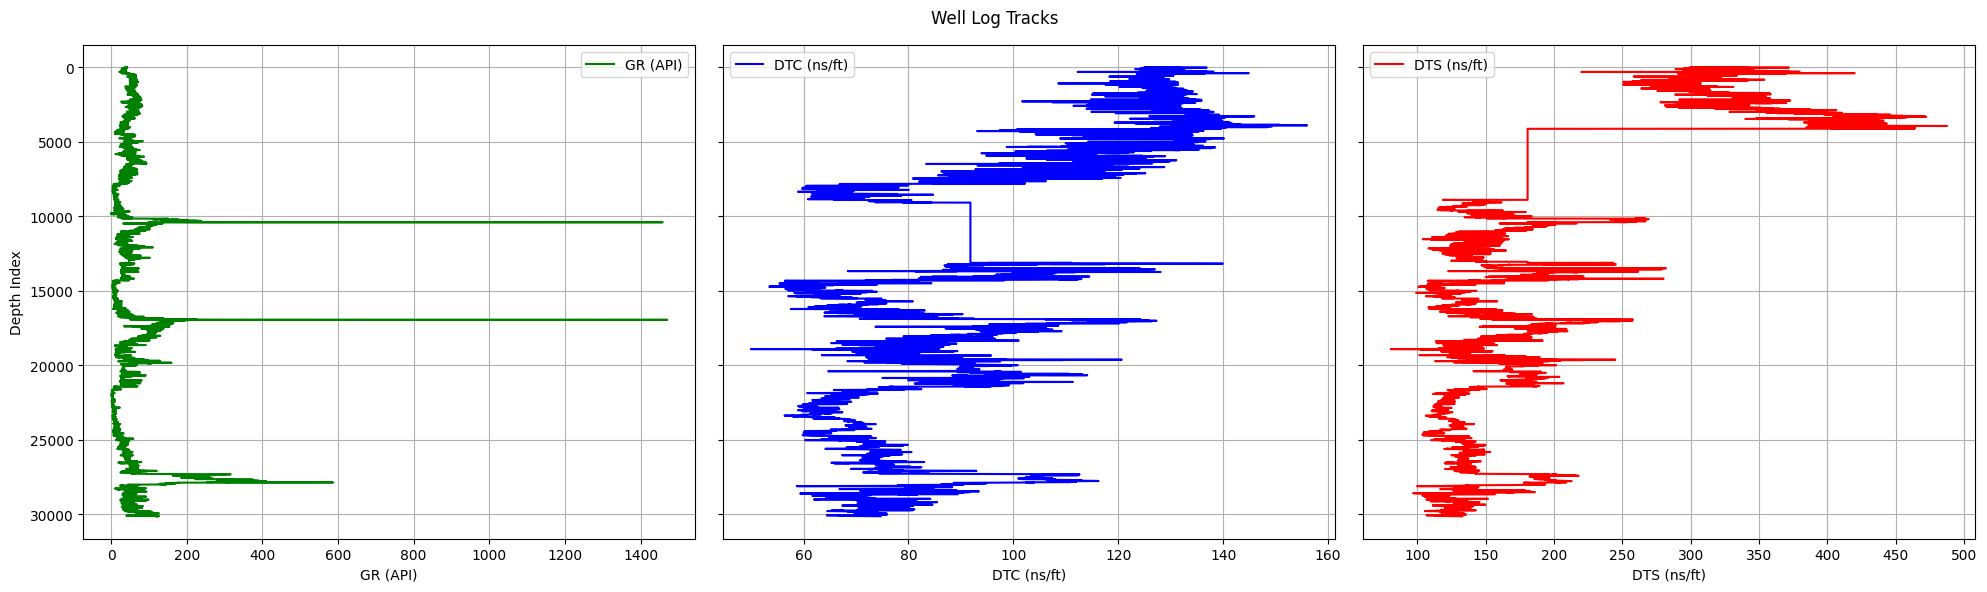

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
ax1.plot(df['GR'], df.index, 'g-', label='GR (API)')
ax1.set_xlabel('GR (API)')
ax1.set_ylabel('Depth Index')
ax1.invert_yaxis()  # Depth increases downward
ax1.legend()
ax1.grid(True)
ax2.plot(df['DTC'], df.index, 'b-', label='DTC (ns/ft)')
ax2.set_xlabel('DTC (ns/ft)')
ax2.legend()
ax2.grid(True)
ax3.plot(df['DTS'], df.index, 'r-', label='DTS (ns/ft)')
ax3.set_xlabel('DTS (ns/ft)')
ax3.legend()
ax3.grid(True)
plt.suptitle('Well Log Tracks')
plt.tight_layout()
plt.show()

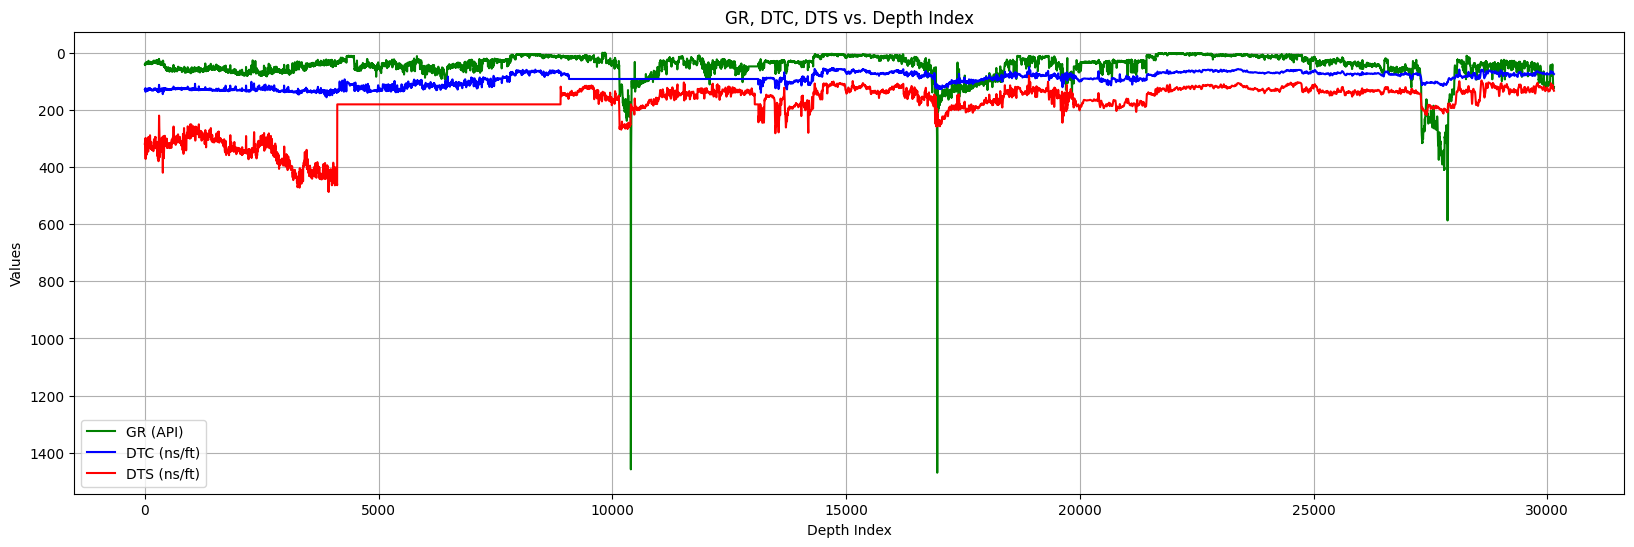

In [15]:
plt.figure(figsize=(20, 6))
plt.plot(df.index, df['GR'], 'g-', label='GR (API)')
plt.plot(df.index, df['DTC'], 'b-', label='DTC (ns/ft)')
plt.plot(df.index, df['DTS'], 'r-', label='DTS (ns/ft)')
plt.xlabel('Depth Index')
plt.ylabel('Values')
plt.title('GR, DTC, DTS vs. Depth Index')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

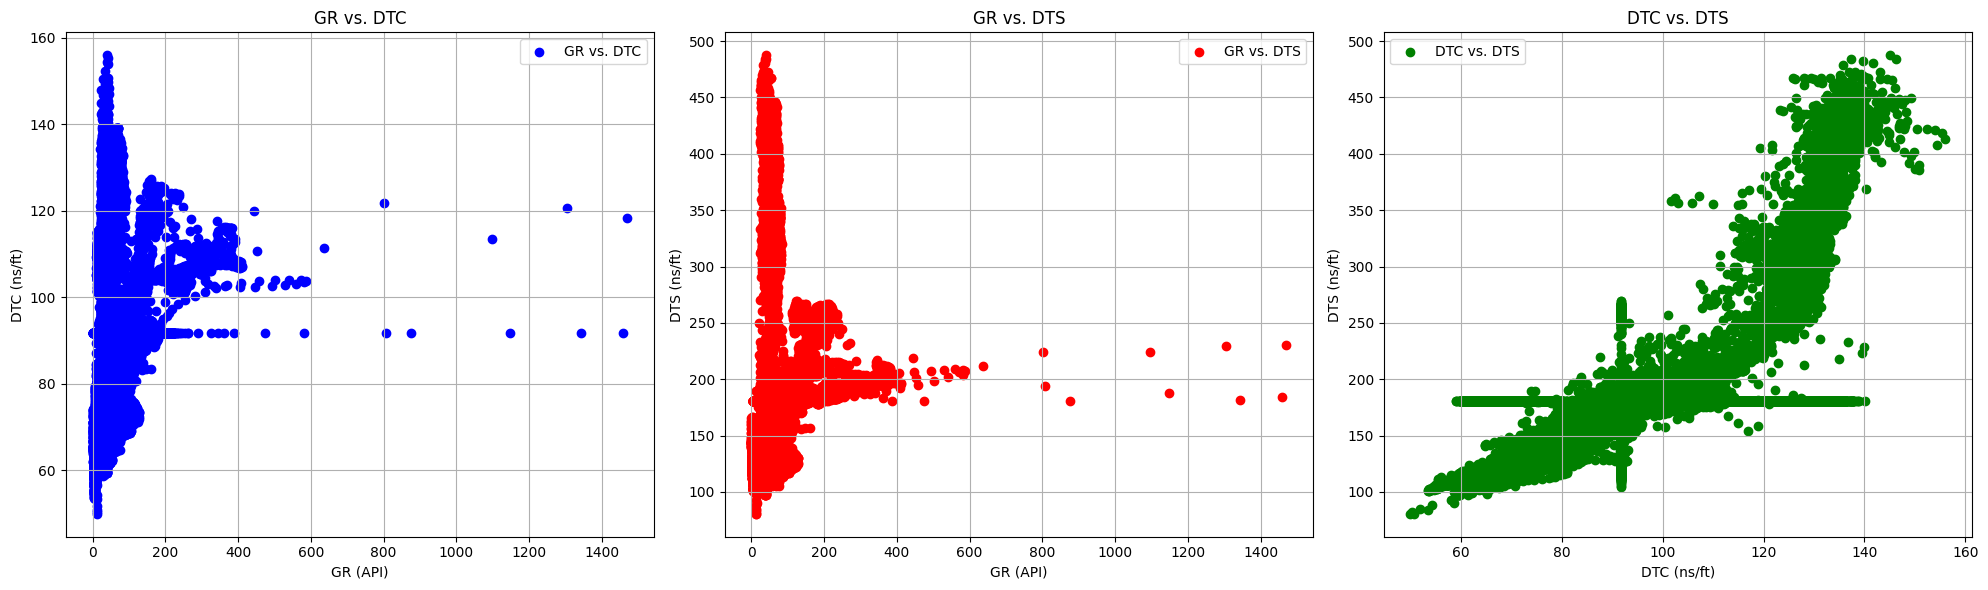

In [16]:
plt.figure(figsize=(20, 6))
plt.subplot(131)
plt.scatter(df['GR'], df['DTC'], c='blue', label='GR vs. DTC')
plt.xlabel('GR (API)')
plt.ylabel('DTC (ns/ft)')
plt.title('GR vs. DTC')
plt.legend()
plt.grid(True)
plt.subplot(132)
plt.scatter(df['GR'], df['DTS'], c='red', label='GR vs. DTS')
plt.xlabel('GR (API)')
plt.ylabel('DTS (ns/ft)')
plt.title('GR vs. DTS')
plt.legend()
plt.grid(True)
plt.subplot(133)
plt.scatter(df['DTC'], df['DTS'], c='green', label='DTC vs. DTS')
plt.xlabel('DTC (ns/ft)')
plt.ylabel('DTS (ns/ft)')
plt.title('DTC vs. DTS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

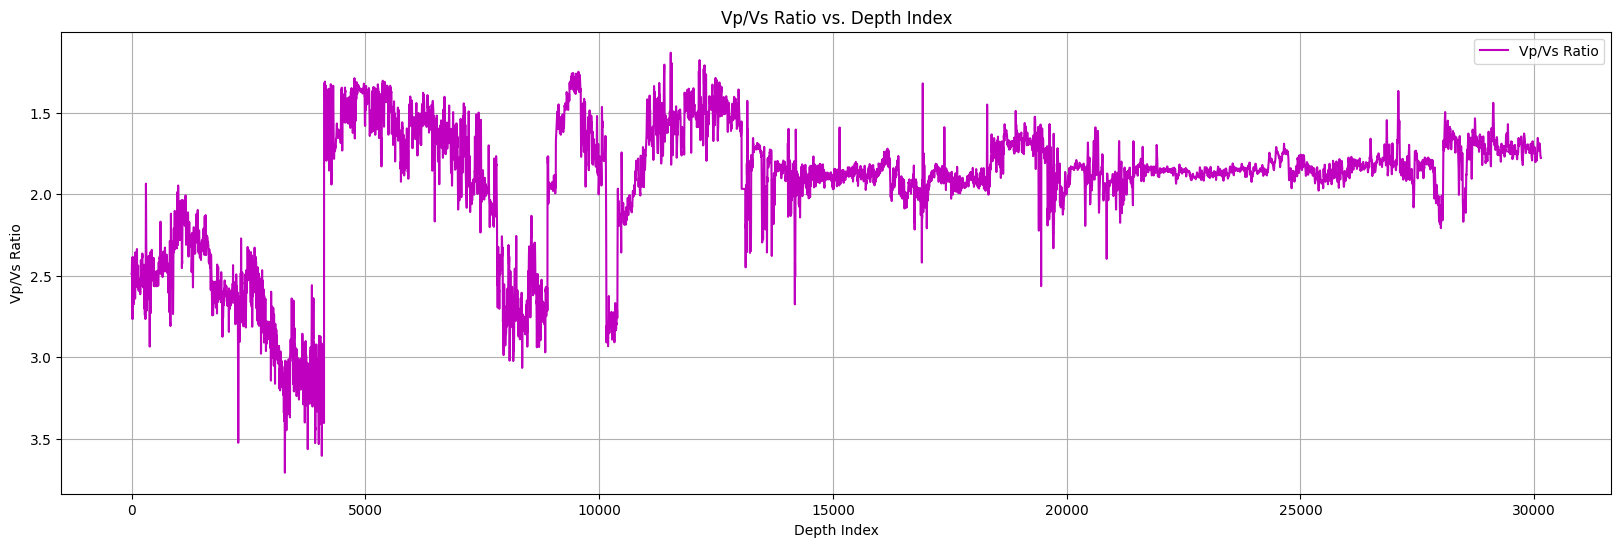

In [17]:
df['Vp_Vs'] = df['DTS'] / df['DTC']  # Vp/Vs = DTS/DTC
plt.figure(figsize=(20, 6))
plt.plot(df.index, df['Vp_Vs'], 'm-', label='Vp/Vs Ratio')
plt.xlabel('Depth Index')
plt.ylabel('Vp/Vs Ratio')
plt.title('Vp/Vs Ratio vs. Depth Index')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

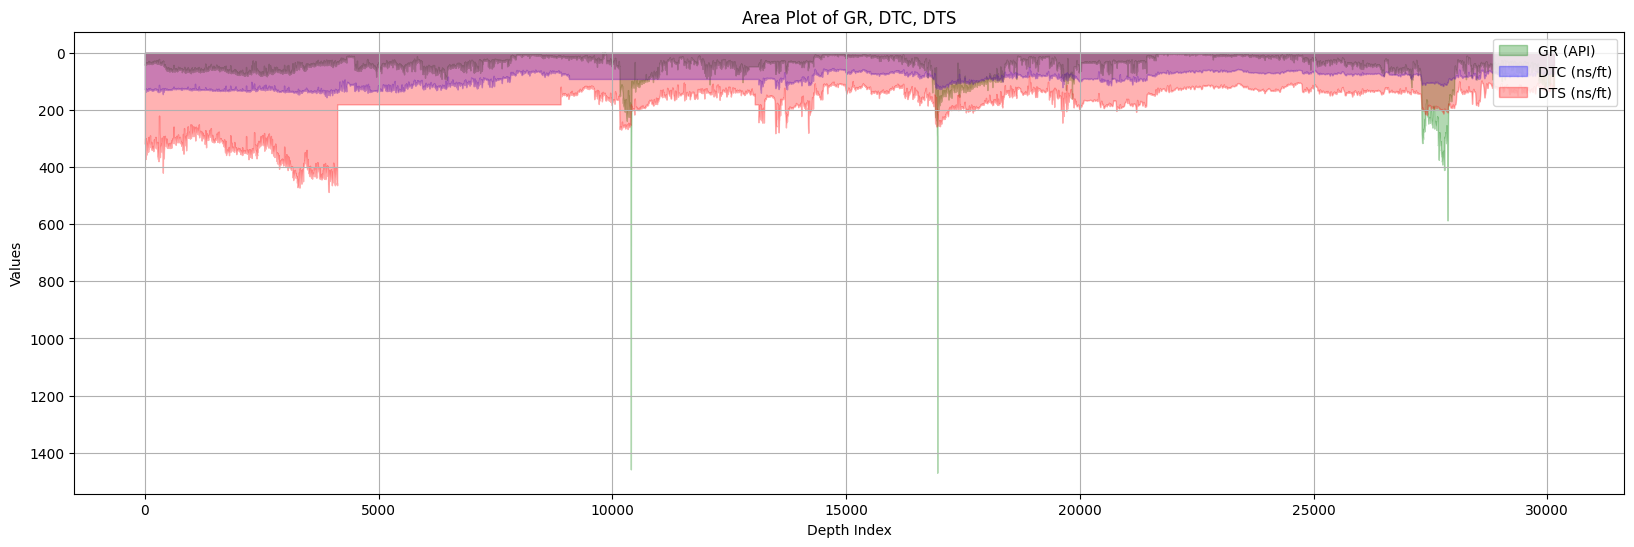

In [18]:
plt.figure(figsize=(20, 6))
plt.fill_between(df.index, df['GR'], color='green', alpha=0.3, label='GR (API)')
plt.fill_between(df.index, df['DTC'], color='blue', alpha=0.3, label='DTC (ns/ft)')
plt.fill_between(df.index, df['DTS'], color='red', alpha=0.3, label='DTS (ns/ft)')
plt.xlabel('Depth Index')
plt.ylabel('Values')
plt.title('Area Plot of GR, DTC, DTS')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()


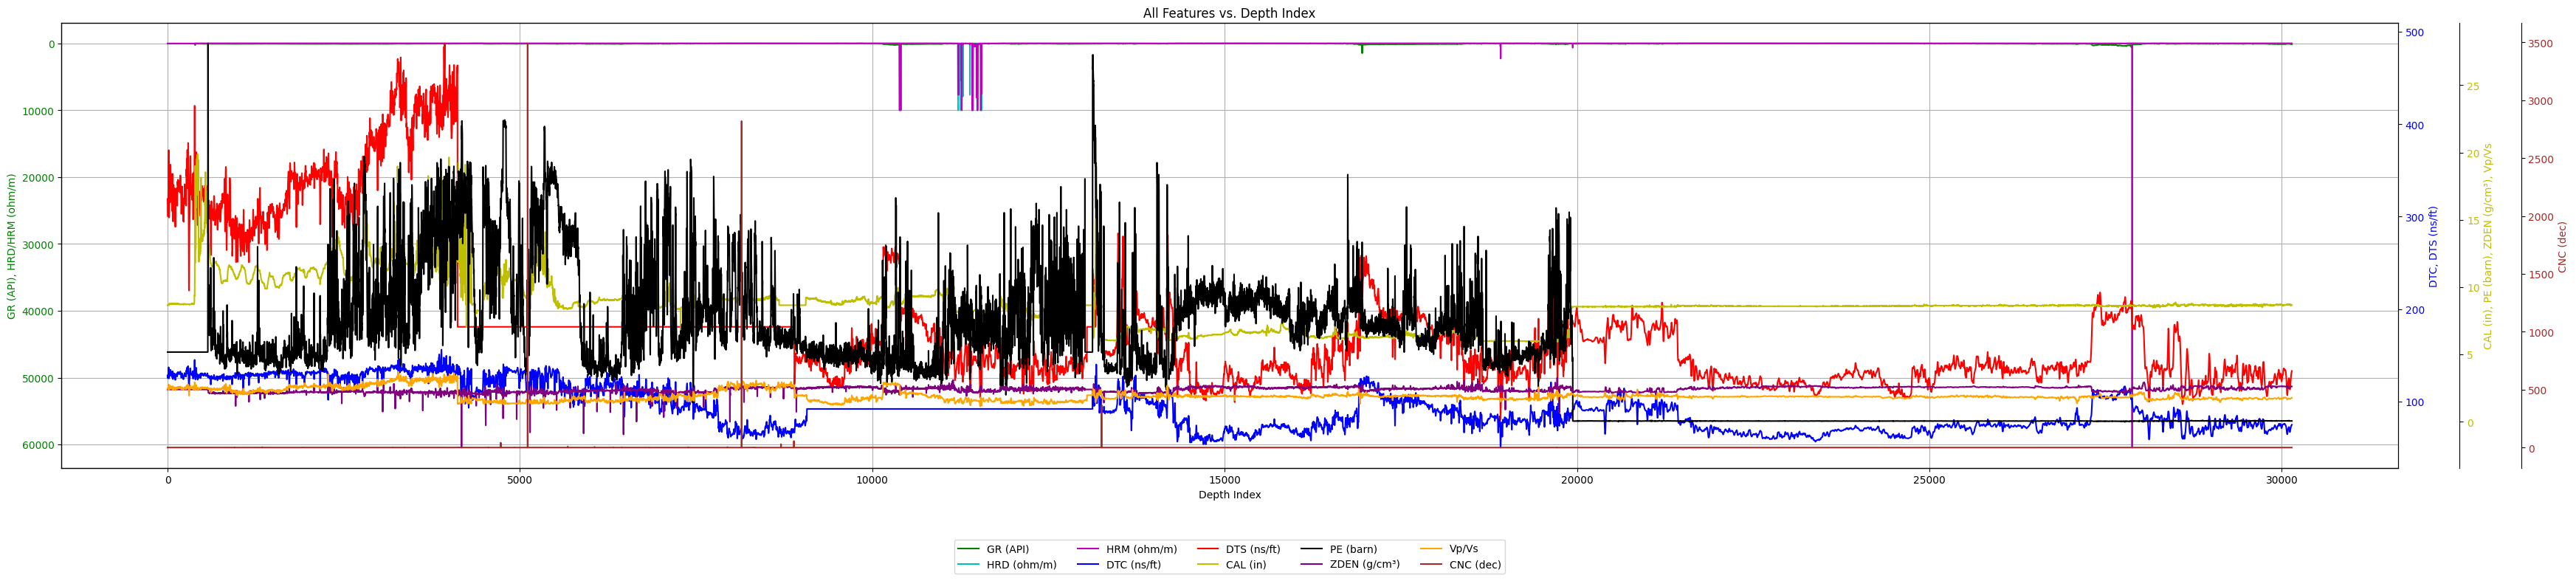

In [19]:
# Create a single plot with multiple y-axes
fig, ax1 = plt.subplots(figsize=(35, 8))

# Plot GR, HRD, HRM (similar scales: ~14–43)
ax1.plot(df.index, df['GR'], 'g-', label='GR (API)')
ax1.plot(df.index, df['HRD'], 'c-', label='HRD (ohm/m)')
ax1.plot(df.index, df['HRM'], 'm-', label='HRM (ohm/m)')
ax1.set_xlabel('Depth Index')
ax1.set_ylabel('GR (API), HRD/HRM (ohm/m)', color='g')
ax1.tick_params(axis='y', labelcolor='g')
ax1.grid(True)

# Second y-axis for DTC, DTS (travel times: ~125–319 ns/ft)
ax2 = ax1.twinx()
ax2.plot(df.index, df['DTC'], 'b-', label='DTC (ns/ft)')
ax2.plot(df.index, df['DTS'], 'r-', label='DTS (ns/ft)')
ax2.set_ylabel('DTC, DTS (ns/ft)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Third y-axis for CAL, PE, ZDEN, Vp_Vs (smaller scales: ~0.6–8.6)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset third axis
ax3.plot(df.index, df['CAL'], 'y-', label='CAL (in)')
ax3.plot(df.index, df['PE'], 'k-', label='PE (barn)')
ax3.plot(df.index, df['ZDEN'], 'purple', linestyle='-', label='ZDEN (g/cm³)')
ax3.plot(df.index, df['Vp_Vs'], 'orange', linestyle='-', label='Vp/Vs')
ax3.set_ylabel('CAL (in), PE (barn), ZDEN (g/cm³), Vp/Vs', color='y')
ax3.tick_params(axis='y', labelcolor='y')

# Fourth y-axis for CNC (very small scale: ~0.683)
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 120))  # Offset fourth axis
ax4.plot(df.index, df['CNC'], 'brown', linestyle='-', label='CNC (dec)')
ax4.set_ylabel('CNC (dec)', color='brown')
ax4.tick_params(axis='y', labelcolor='brown')

# Combine legends from all axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3 + lines4, labels1 + labels2 + labels3 + labels4, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

# Invert y-axis for depth increasing downward
ax1.invert_yaxis()

# Set title
plt.title('All Features vs. Depth Index')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plot
plt.show()

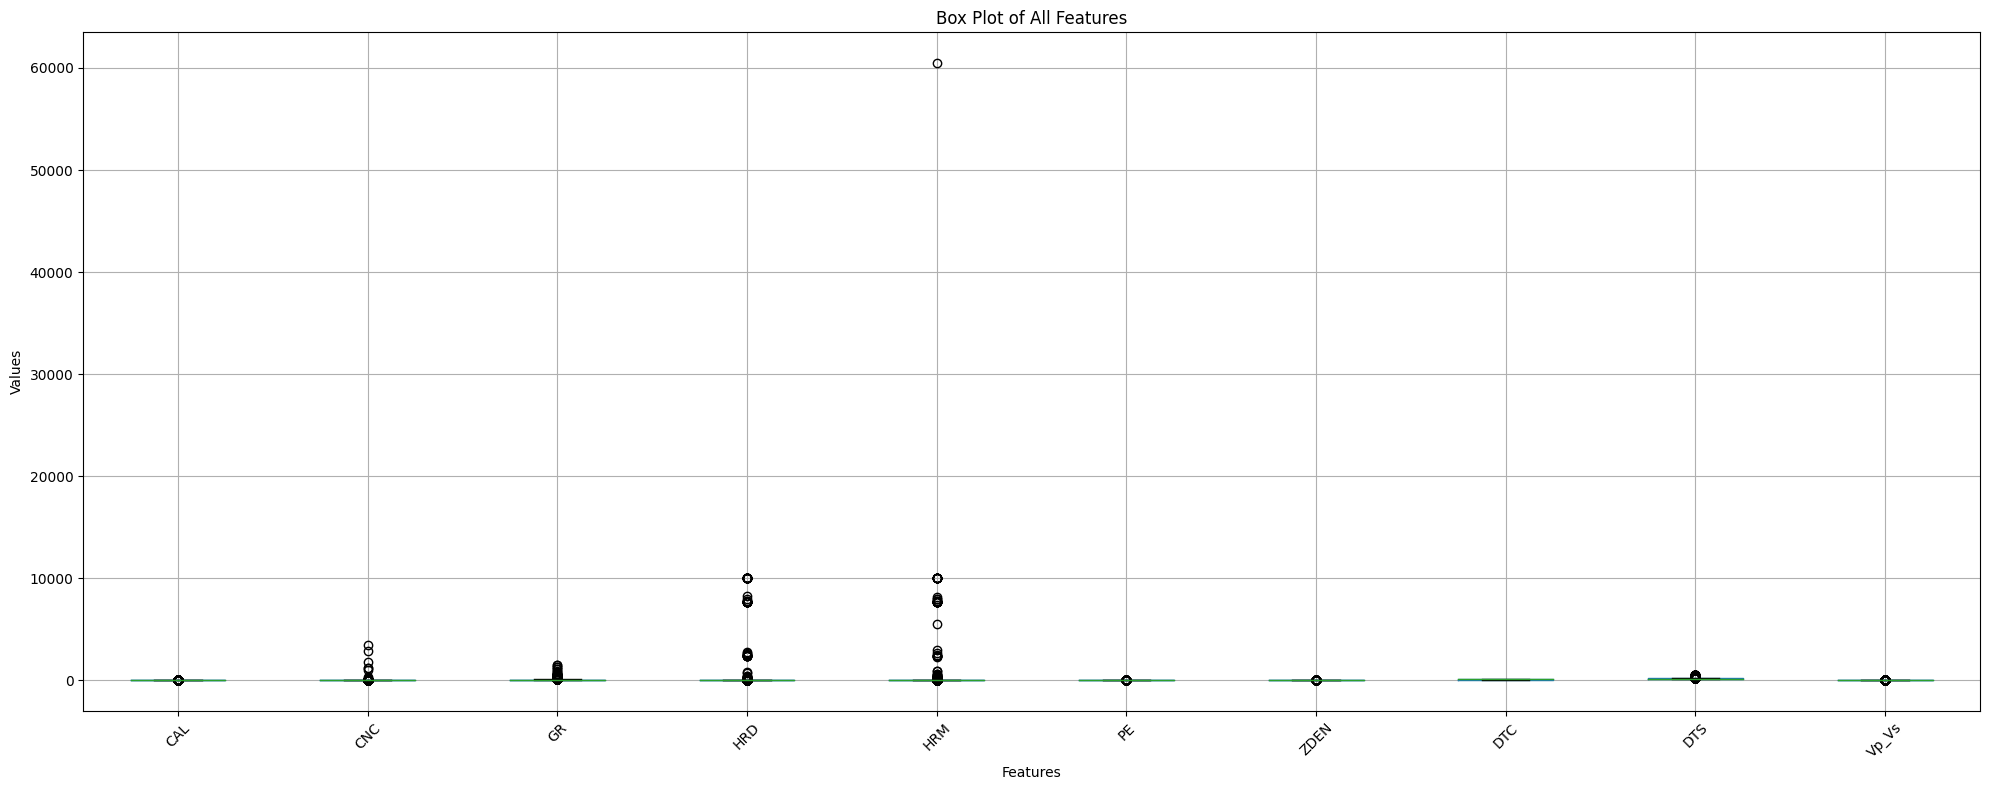

In [20]:
plt.figure(figsize=(20, 8))
df.boxplot(column=['CAL', 'CNC', 'GR', 'HRD', 'HRM', 'PE', 'ZDEN', 'DTC', 'DTS', 'Vp_Vs'])
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Box Plot of All Features')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [21]:
df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264
1,8.654281,0.683437,42.5053,16.953912,14.492077,5.173227,2.393818,127.8347,318.7825,2.493709
2,8.654281,0.683437,43.1548,16.953912,14.492077,5.173227,2.393818,127.2307,317.3323,2.494149
3,8.654281,0.683437,43.2410,16.953912,14.492077,5.173227,2.393818,126.2917,313.6486,2.483525
4,8.654281,0.683437,40.3218,16.953912,14.492077,5.173227,2.393818,125.3985,307.8903,2.455295


In [22]:
df_dtc=df.copy()
df_dtc_x = df_dtc.drop(columns=['DTC','DTS'])
y_dtc = df_dtc['DTC']

In [23]:
X_train_dtc, X_test_dtc, y_train_dtc, y_test_dtc = train_test_split(df_dtc_x, y_dtc, test_size=0.2, random_state=42)
print("X_train_dtc shape:", X_train_dtc.shape)
print("X_test_dtc shape:", X_test_dtc.shape)
print("y_train_dtc shape:", y_train_dtc.shape)
print("y_test_dtc shape:", y_test_dtc.shape)

X_train_dtc shape: (24114, 8)
X_test_dtc shape: (6029, 8)
y_train_dtc shape: (24114,)
y_test_dtc shape: (6029,)


In [24]:
model_dtc = CatBoostRegressor(verbose=100,iterations=1000,learning_rate=0.1, random_state=42)
model_dtc.fit(X_train_dtc, y_train_dtc)

0:	learn: 20.6430392	total: 68.5ms	remaining: 1m 8s
100:	learn: 3.2724222	total: 1.65s	remaining: 14.7s
200:	learn: 2.7794012	total: 3.37s	remaining: 13.4s
300:	learn: 2.5102784	total: 5.24s	remaining: 12.2s
400:	learn: 2.3270620	total: 8.12s	remaining: 12.1s
500:	learn: 2.1842572	total: 9.31s	remaining: 9.27s
600:	learn: 2.0617936	total: 11.4s	remaining: 7.56s
700:	learn: 1.9709270	total: 12.5s	remaining: 5.34s
800:	learn: 1.8920437	total: 14.2s	remaining: 3.52s
900:	learn: 1.8221973	total: 16.2s	remaining: 1.78s
999:	learn: 1.7569485	total: 18.5s	remaining: 0us


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_dtc = model_dtc.predict(X_test_dtc)

# Calculate metrics
mae = mean_absolute_error(y_test_dtc, y_pred_dtc)
mse = mean_squared_error(y_test_dtc, y_pred_dtc)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_dtc, y_pred_dtc)

# Print metrics
print("DTC Prediction Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

DTC Prediction Metrics:
Mean Absolute Error (MAE): 1.4819
Mean Squared Error (MSE): 5.7600
Root Mean Squared Error (RMSE): 2.4000
R-squared (R²): 0.9887


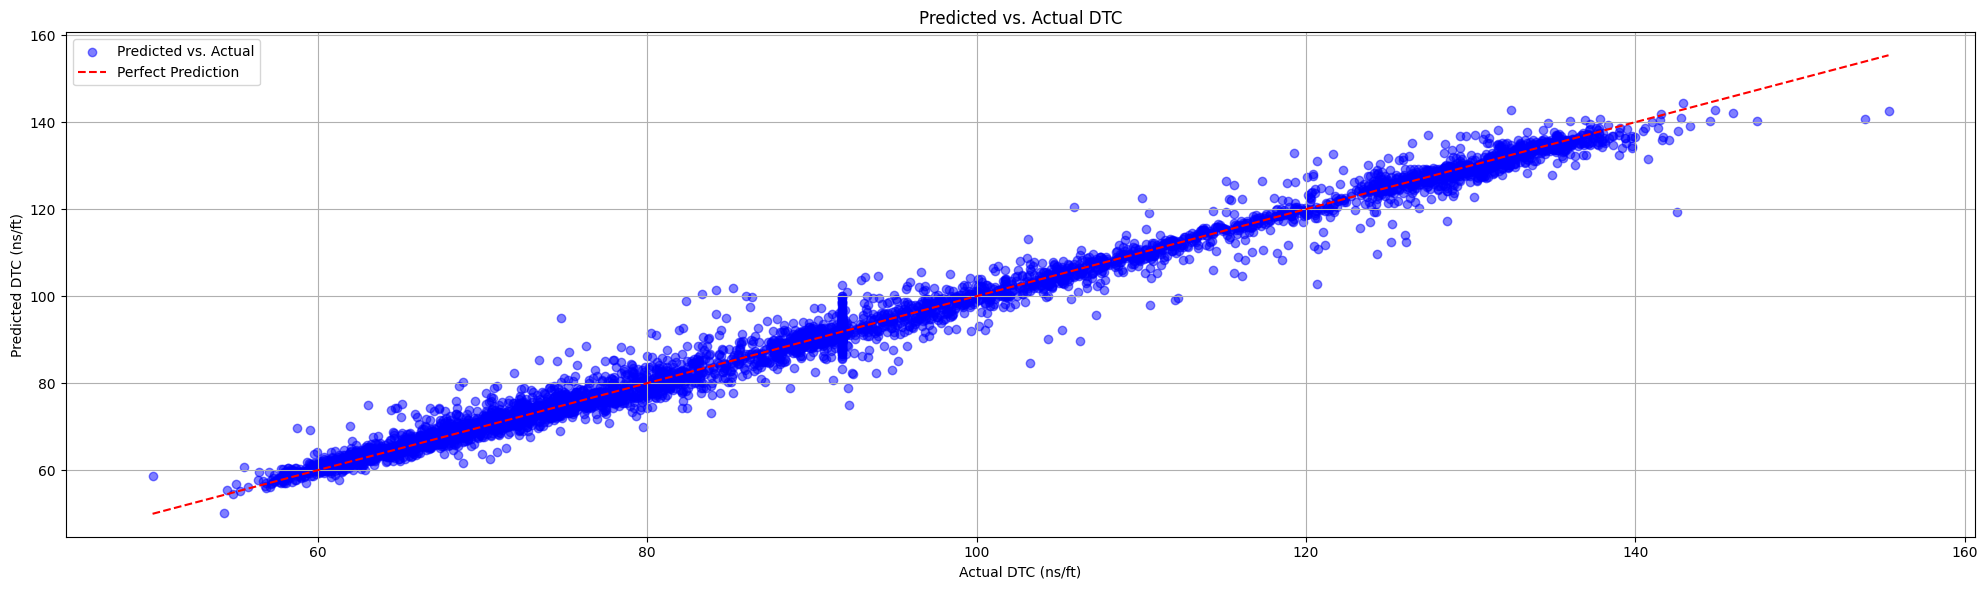

In [26]:
plt.figure(figsize=(20, 6))
plt.scatter(y_test_dtc, y_pred_dtc, color='blue', alpha=0.5, label='Predicted vs. Actual')
plt.plot([y_test_dtc.min(), y_test_dtc.max()], [y_test_dtc.min(), y_test_dtc.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual DTC (ns/ft)')
plt.ylabel('Predicted DTC (ns/ft)')
plt.title('Predicted vs. Actual DTC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

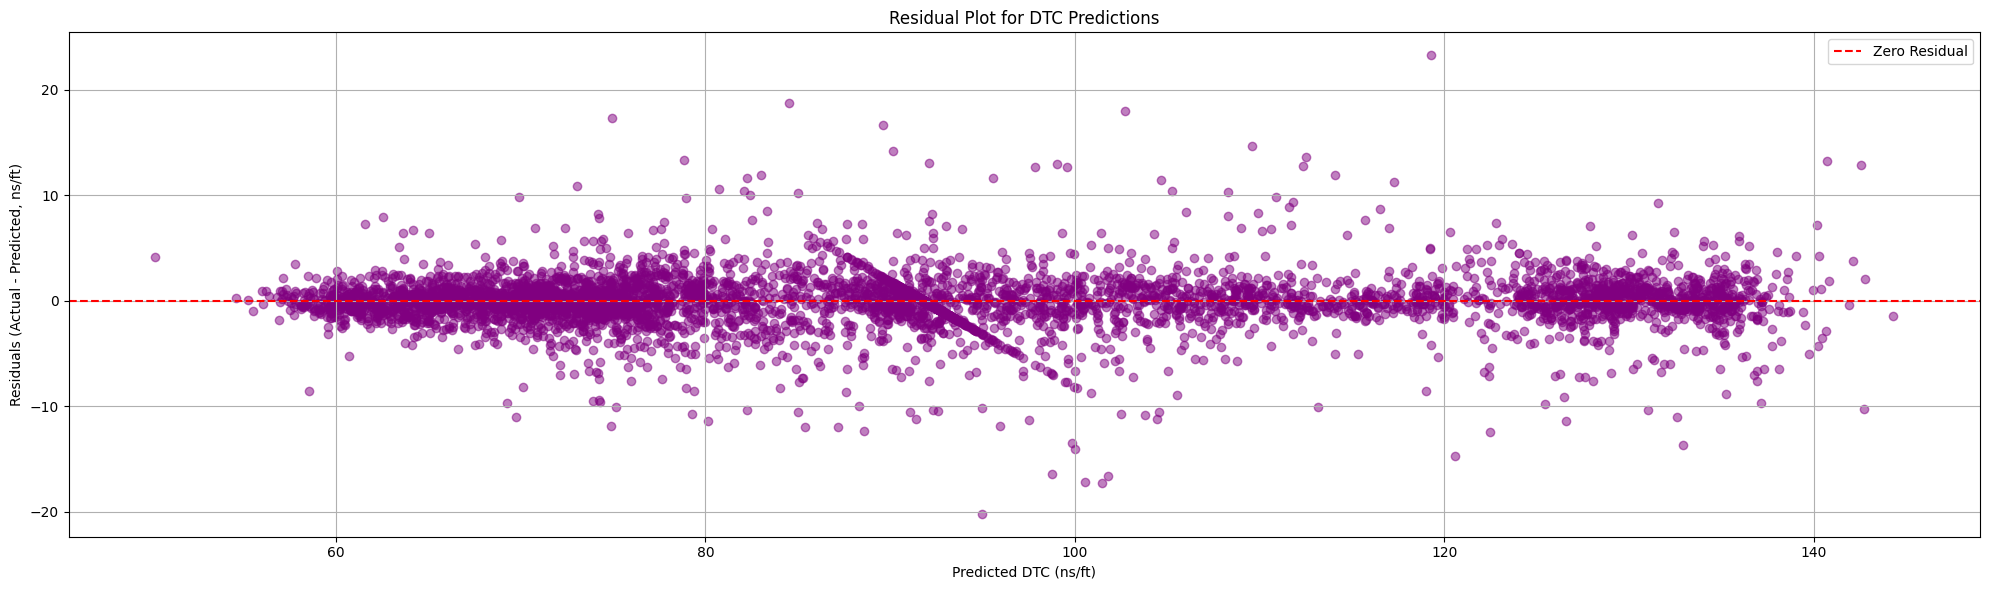

In [27]:
residuals = y_test_dtc - y_pred_dtc
plt.figure(figsize=(20, 6))
plt.scatter(y_pred_dtc, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual')
plt.xlabel('Predicted DTC (ns/ft)')
plt.ylabel('Residuals (Actual - Predicted, ns/ft)')
plt.title('Residual Plot for DTC Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

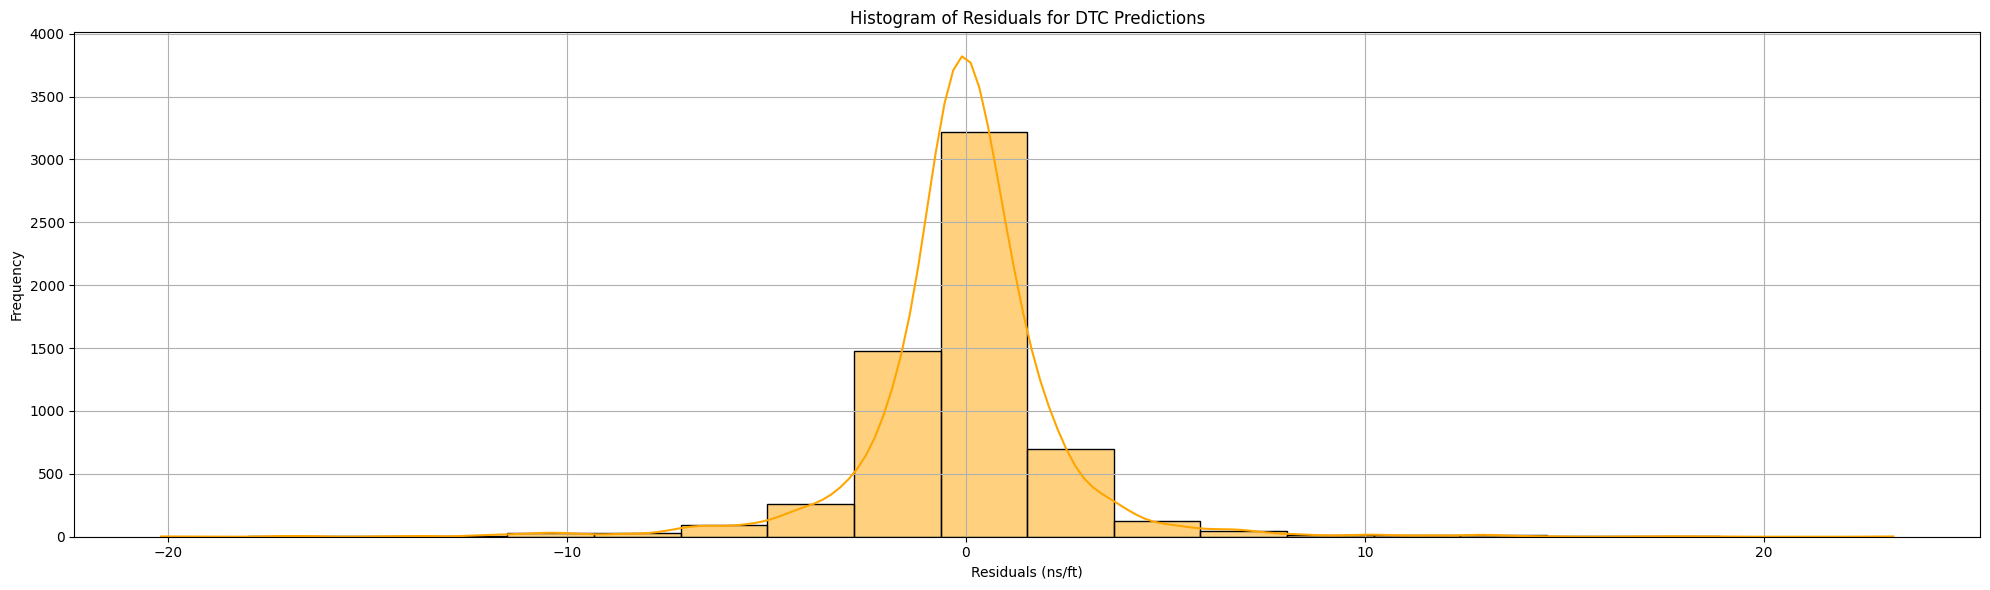

In [28]:
plt.figure(figsize=(20, 6))
sns.histplot(residuals, bins=20, kde=True, color='orange')
plt.xlabel('Residuals (ns/ft)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals for DTC Predictions')
plt.grid(True)
plt.tight_layout()
plt.show()

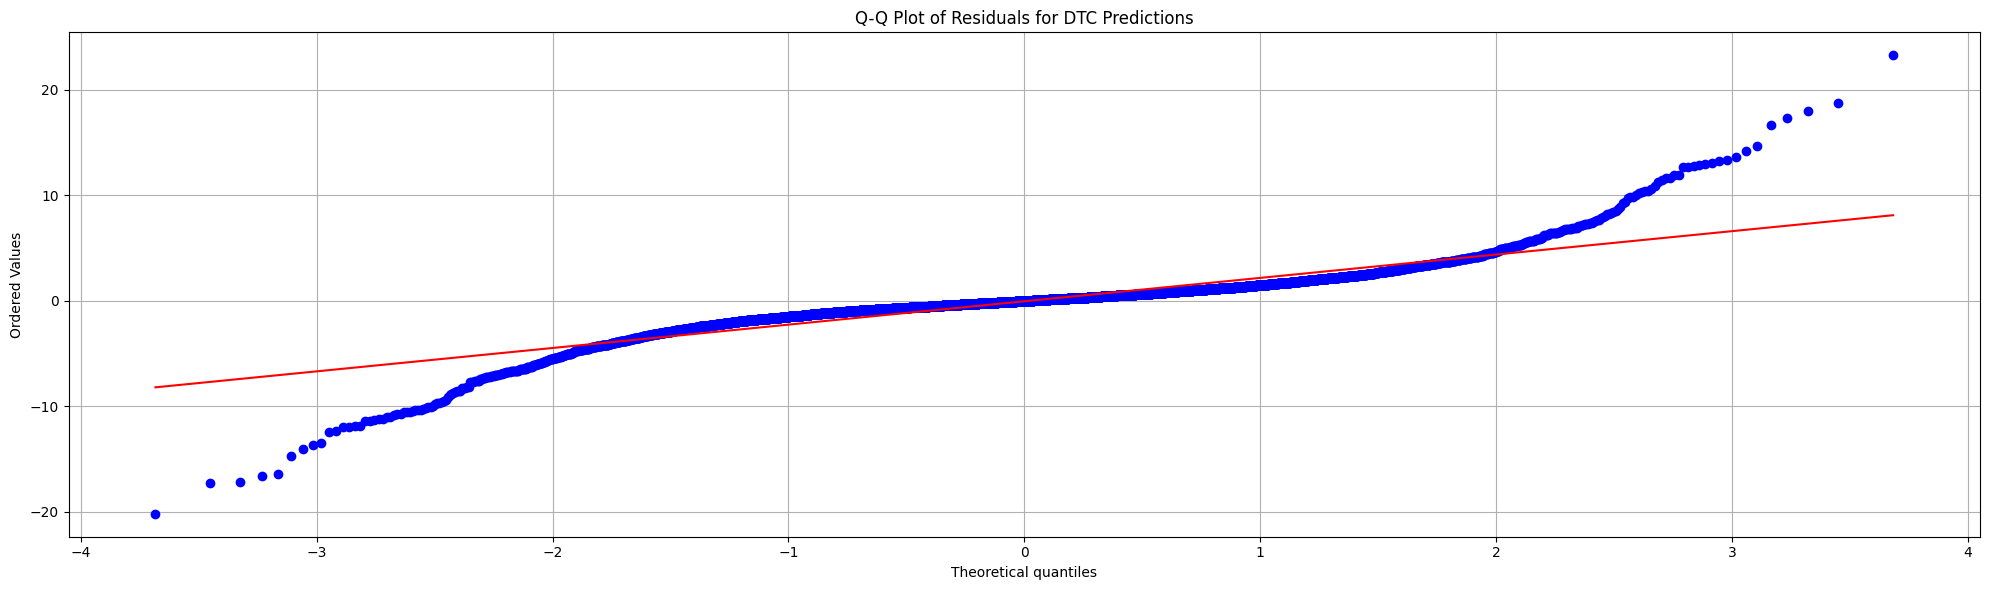

In [29]:
import scipy.stats as stats
plt.figure(figsize=(20, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals for DTC Predictions')
plt.grid(True)
plt.tight_layout()
plt.show()

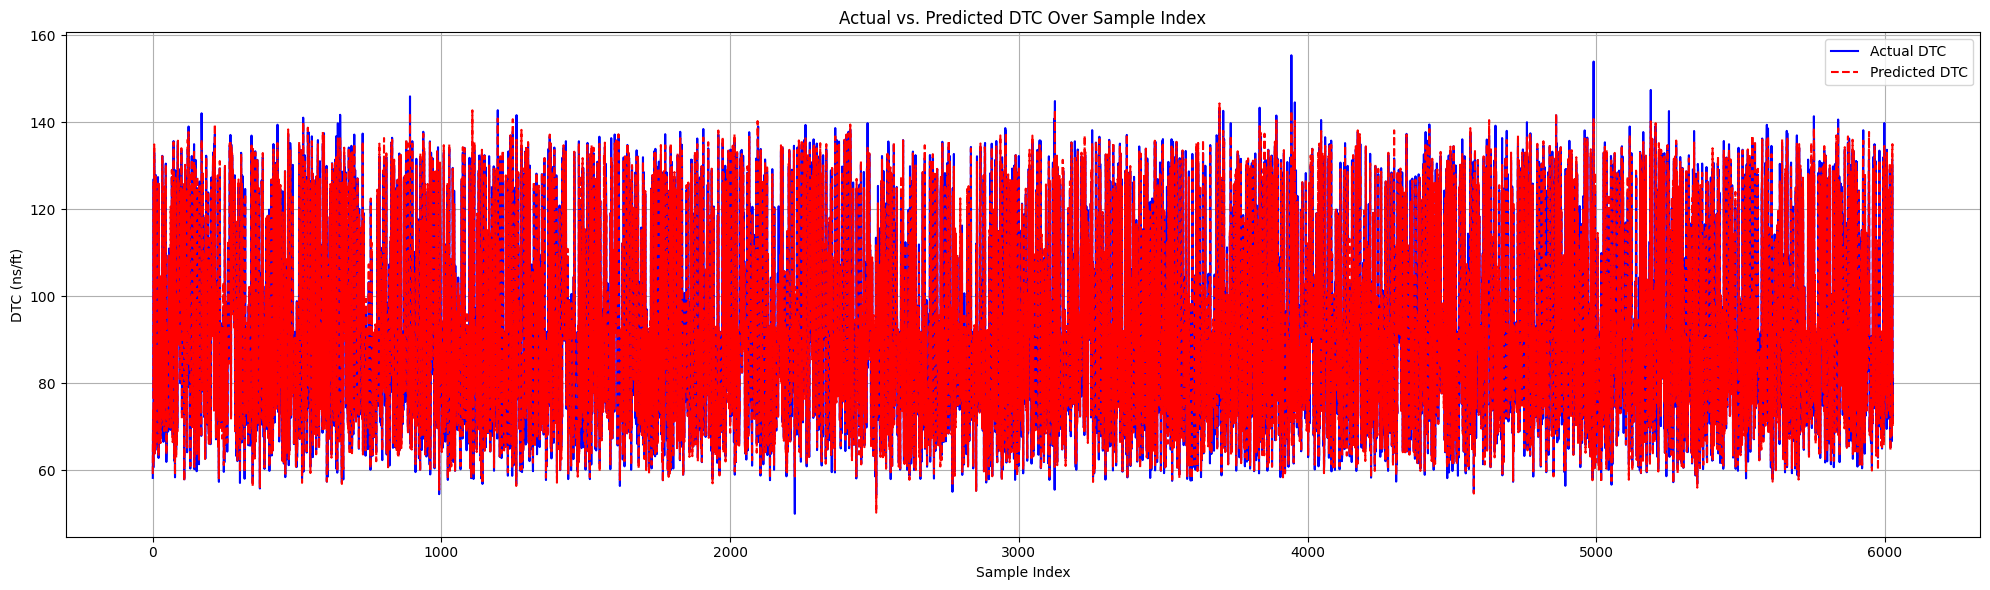

In [30]:
plt.figure(figsize=(20, 6))
plt.plot(range(len(y_test_dtc)), y_test_dtc, 'b-', label='Actual DTC')
plt.plot(range(len(y_pred_dtc)), y_pred_dtc, 'r--', label='Predicted DTC')
plt.xlabel('Sample Index')
plt.ylabel('DTC (ns/ft)')
plt.title('Actual vs. Predicted DTC Over Sample Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

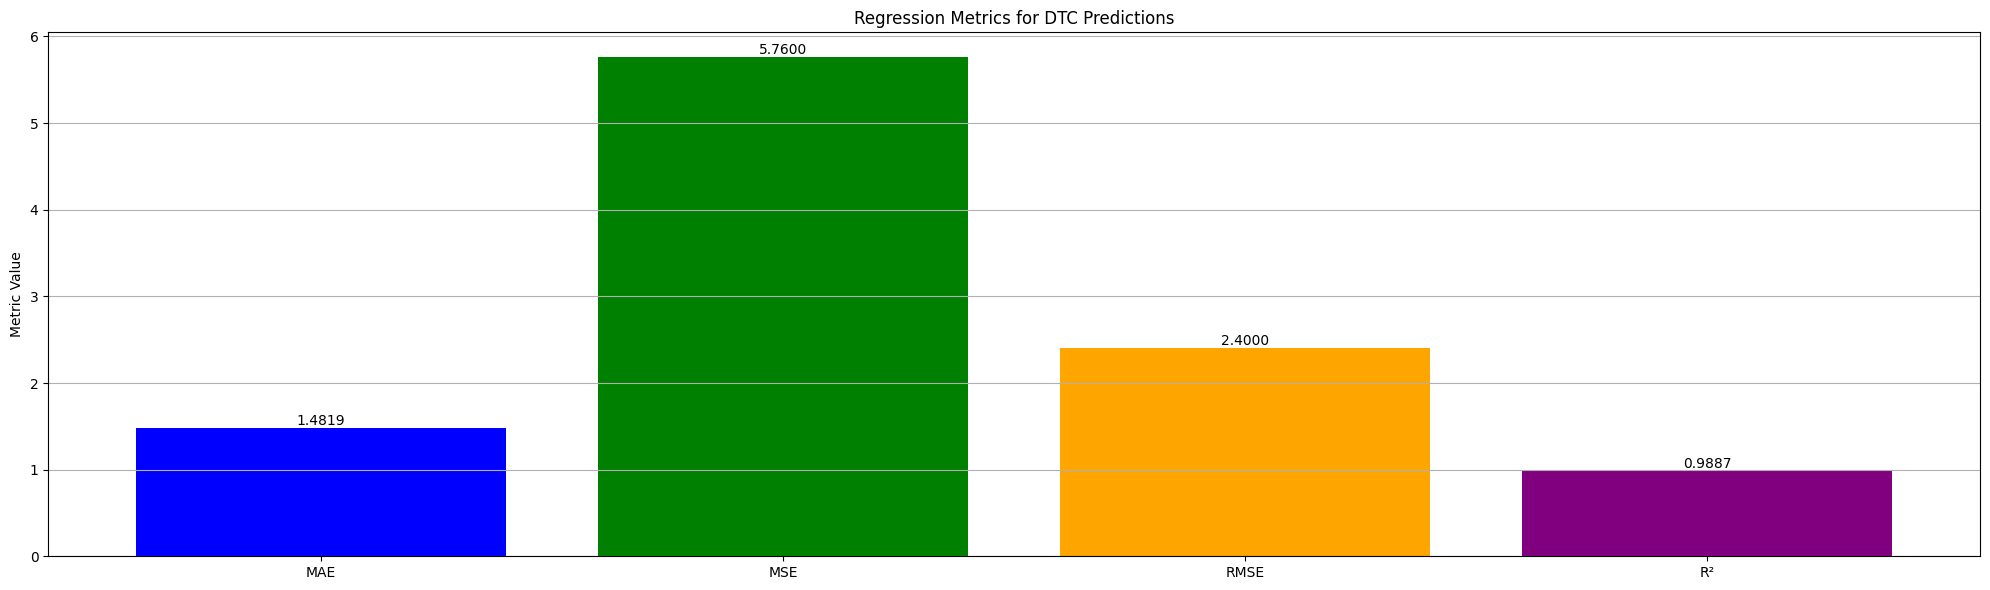

In [31]:
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}
plt.figure(figsize=(20, 6))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'orange', 'purple'])
plt.ylabel('Metric Value')
plt.title('Regression Metrics for DTC Predictions')
for i, v in enumerate(metrics.values()):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

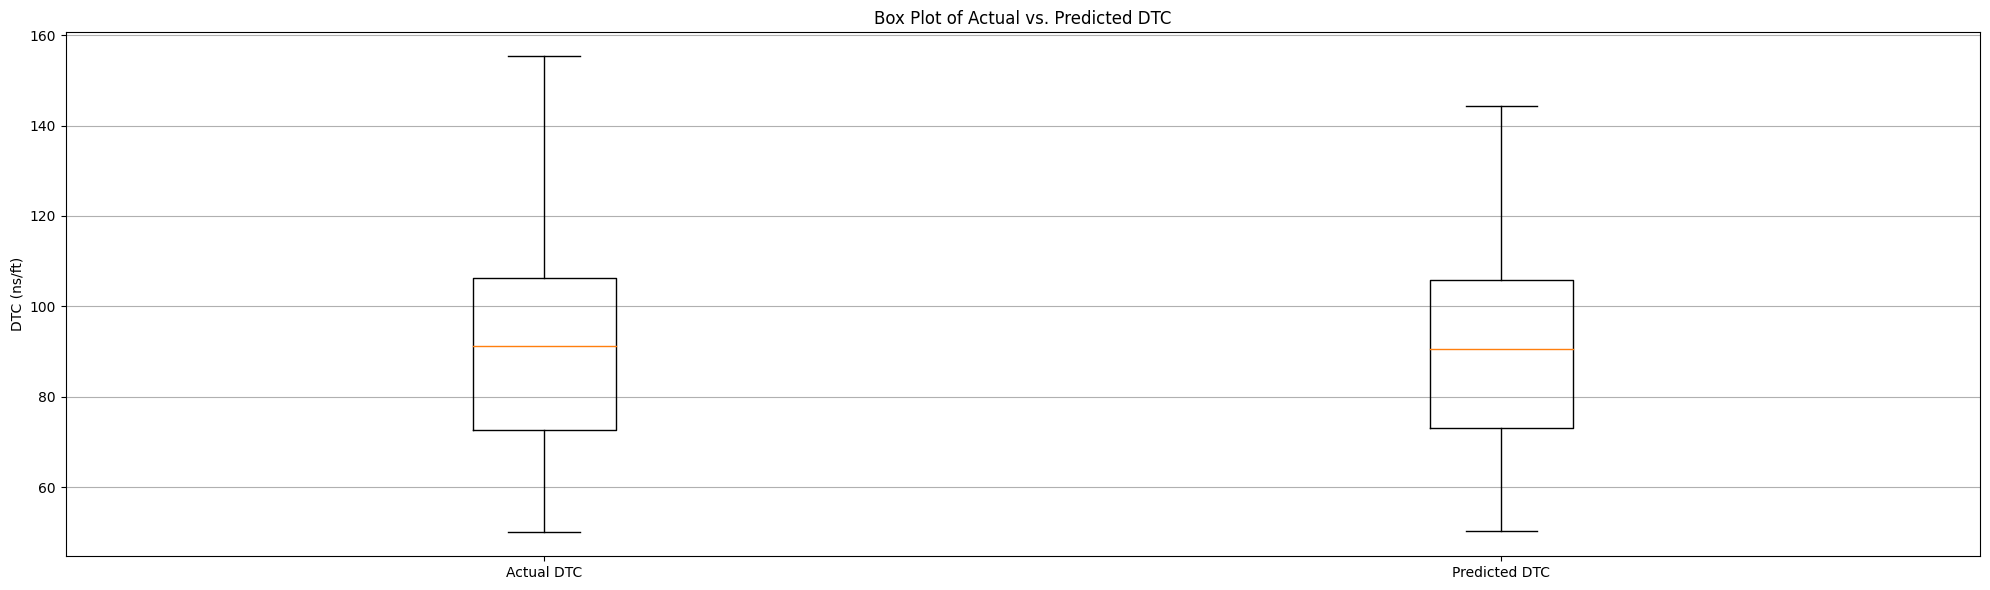

In [32]:
plt.figure(figsize=(20, 6))
plt.boxplot([y_test_dtc, y_pred_dtc], labels=['Actual DTC', 'Predicted DTC'])
plt.ylabel('DTC (ns/ft)')
plt.title('Box Plot of Actual vs. Predicted DTC')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

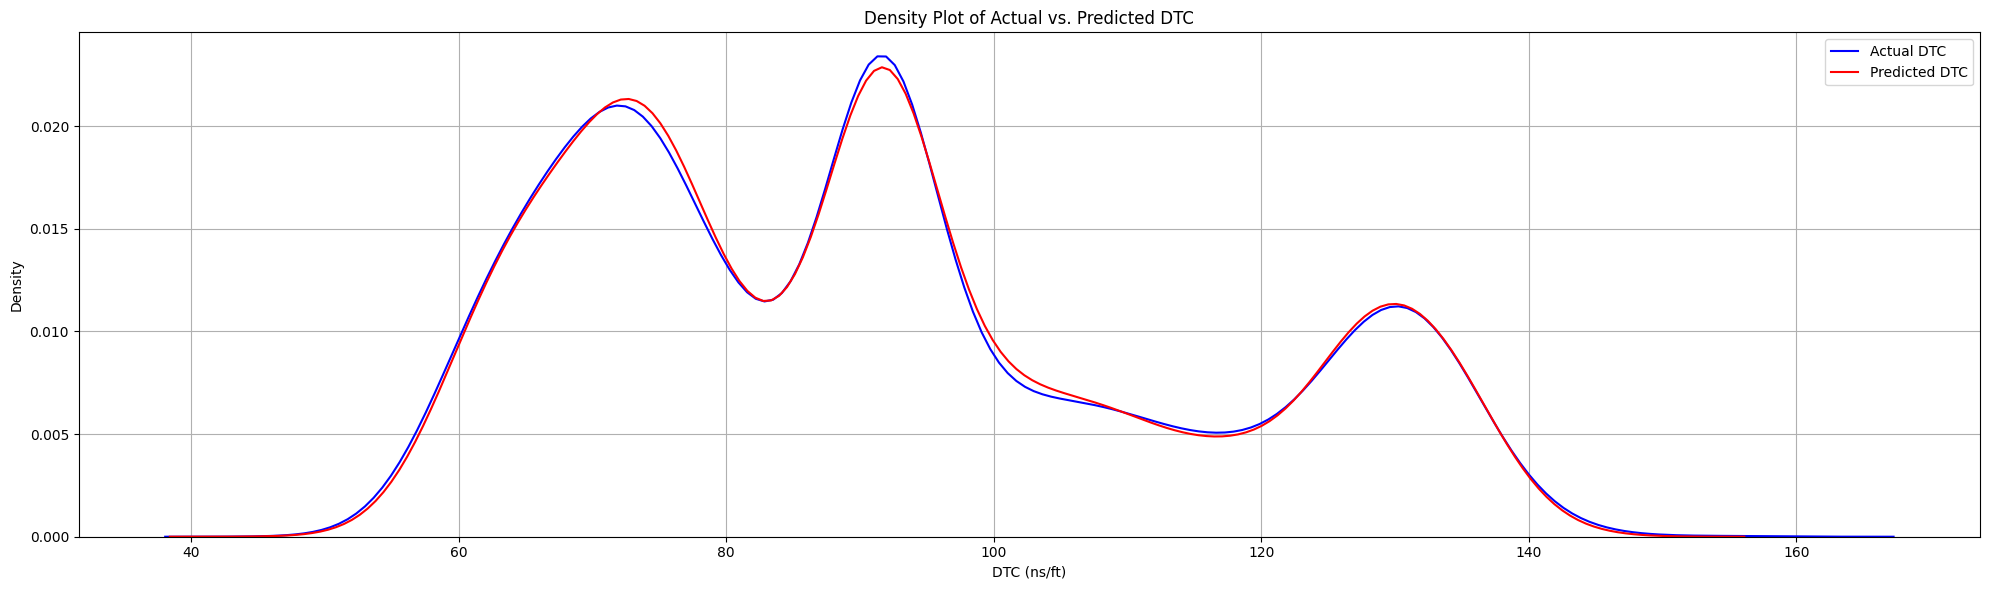

In [33]:
plt.figure(figsize=(20, 6))
sns.kdeplot(y_test_dtc, label='Actual DTC', color='blue')
sns.kdeplot(y_pred_dtc, label='Predicted DTC', color='red')
plt.xlabel('DTC (ns/ft)')
plt.ylabel('Density')
plt.title('Density Plot of Actual vs. Predicted DTC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
fig = px.scatter(x=y_test_dtc, y=y_pred_dtc, labels={'x': 'Actual DTC (ns/ft)', 'y': 'Predicted DTC (ns/ft)'},
                 title='Interactive Predicted vs. Actual DTC')
fig.add_trace(go.Scatter(x=[y_test_dtc.min(), y_test_dtc.max()], y=[y_test_dtc.min(), y_test_dtc.max()],
                         mode='lines', name='Perfect Prediction', line=dict(color='red', dash='dash')))
fig.show()

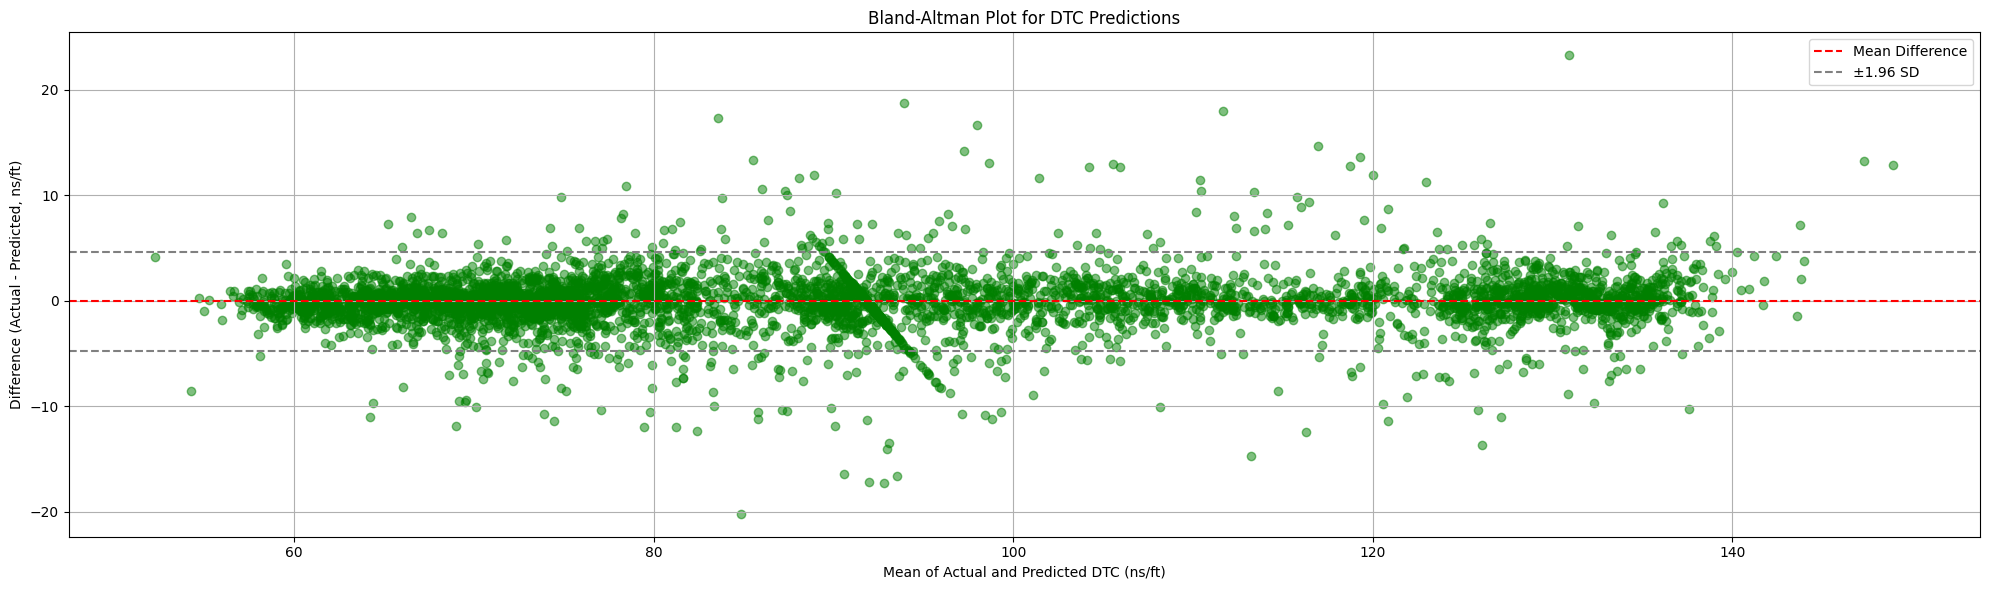

In [35]:
mean_dtc = (y_test_dtc + y_pred_dtc) / 2
diff_dtc = y_test_dtc - y_pred_dtc
plt.figure(figsize=(20, 6))
plt.scatter(mean_dtc, diff_dtc, color='green', alpha=0.5)
plt.axhline(np.mean(diff_dtc), color='red', linestyle='--', label='Mean Difference')
plt.axhline(np.mean(diff_dtc) + 1.96 * np.std(diff_dtc), color='gray', linestyle='--', label='±1.96 SD')
plt.axhline(np.mean(diff_dtc) - 1.96 * np.std(diff_dtc), color='gray', linestyle='--')
plt.xlabel('Mean of Actual and Predicted DTC (ns/ft)')
plt.ylabel('Difference (Actual - Predicted, ns/ft)')
plt.title('Bland-Altman Plot for DTC Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
df_dts=df.copy()
df_dts_x = df_dts.drop(columns=['DTC','DTS'])
y_dts = df_dts['DTC']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df_dts_x, y_dts, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24114, 8)
X_test shape: (6029, 8)
y_train shape: (24114,)
y_test shape: (6029,)


In [38]:
model_dts = CatBoostRegressor(verbose=100,iterations=1000,learning_rate=0.1, random_state=42)
model_dts.fit(X_train, y_train)

0:	learn: 20.6430392	total: 55.6ms	remaining: 55.6s
100:	learn: 3.2724222	total: 1.63s	remaining: 14.5s
200:	learn: 2.7794012	total: 3.35s	remaining: 13.3s
300:	learn: 2.5102784	total: 5.77s	remaining: 13.4s
400:	learn: 2.3270620	total: 7.17s	remaining: 10.7s
500:	learn: 2.1842572	total: 8.7s	remaining: 8.66s
600:	learn: 2.0617936	total: 10s	remaining: 6.67s
700:	learn: 1.9709270	total: 12s	remaining: 5.12s
800:	learn: 1.8920437	total: 14.2s	remaining: 3.53s
900:	learn: 1.8221973	total: 15.5s	remaining: 1.71s
999:	learn: 1.7569485	total: 17.6s	remaining: 0us


In [39]:
y_pred_dts = model_dts.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_dts)
mse = mean_squared_error(y_test, y_pred_dts)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dts)

# Print metrics
print("DTS Prediction Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

DTS Prediction Metrics:
Mean Absolute Error (MAE): 1.4819
Mean Squared Error (MSE): 5.7600
Root Mean Squared Error (RMSE): 2.4000
R-squared (R²): 0.9887


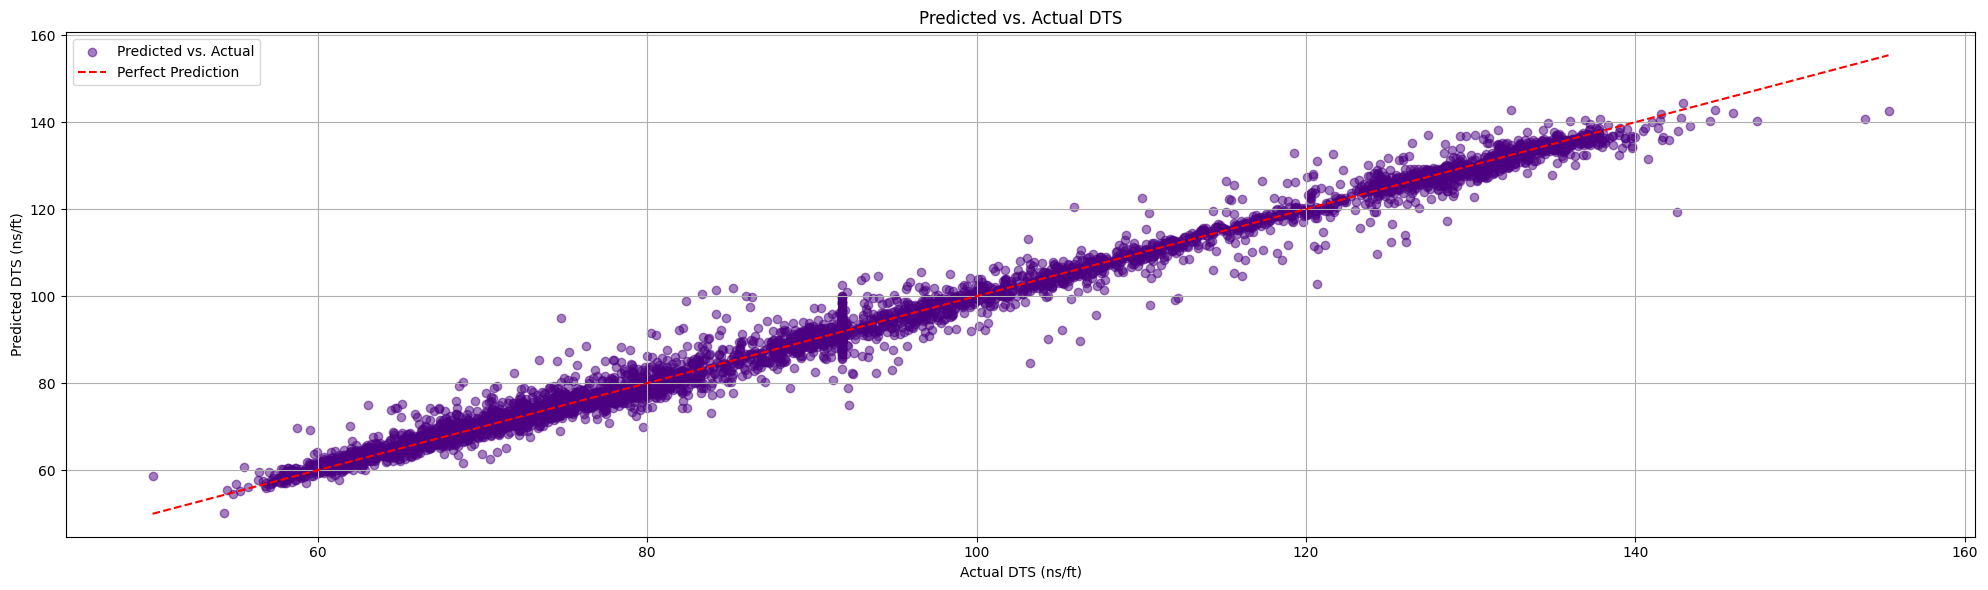

In [40]:
plt.figure(figsize=(20, 6))
plt.scatter(y_test, y_pred_dts, color='indigo', alpha=0.5, label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual DTS (ns/ft)')
plt.ylabel('Predicted DTS (ns/ft)')
plt.title('Predicted vs. Actual DTS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


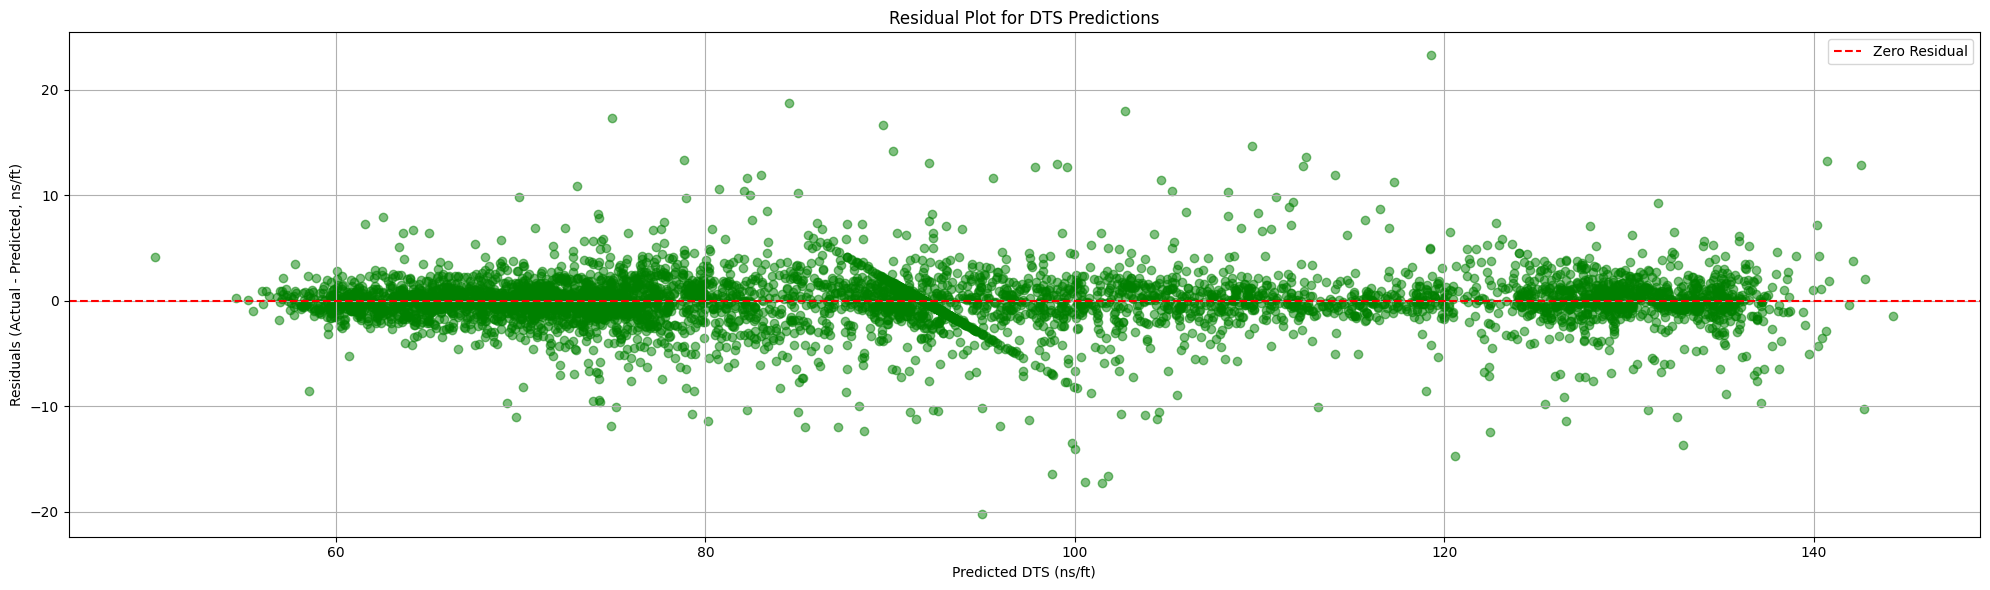

In [41]:
residuals = y_test - y_pred_dts
plt.figure(figsize=(20, 6))
plt.scatter(y_pred_dts, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual')
plt.xlabel('Predicted DTS (ns/ft)')
plt.ylabel('Residuals (Actual - Predicted, ns/ft)')
plt.title('Residual Plot for DTS Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

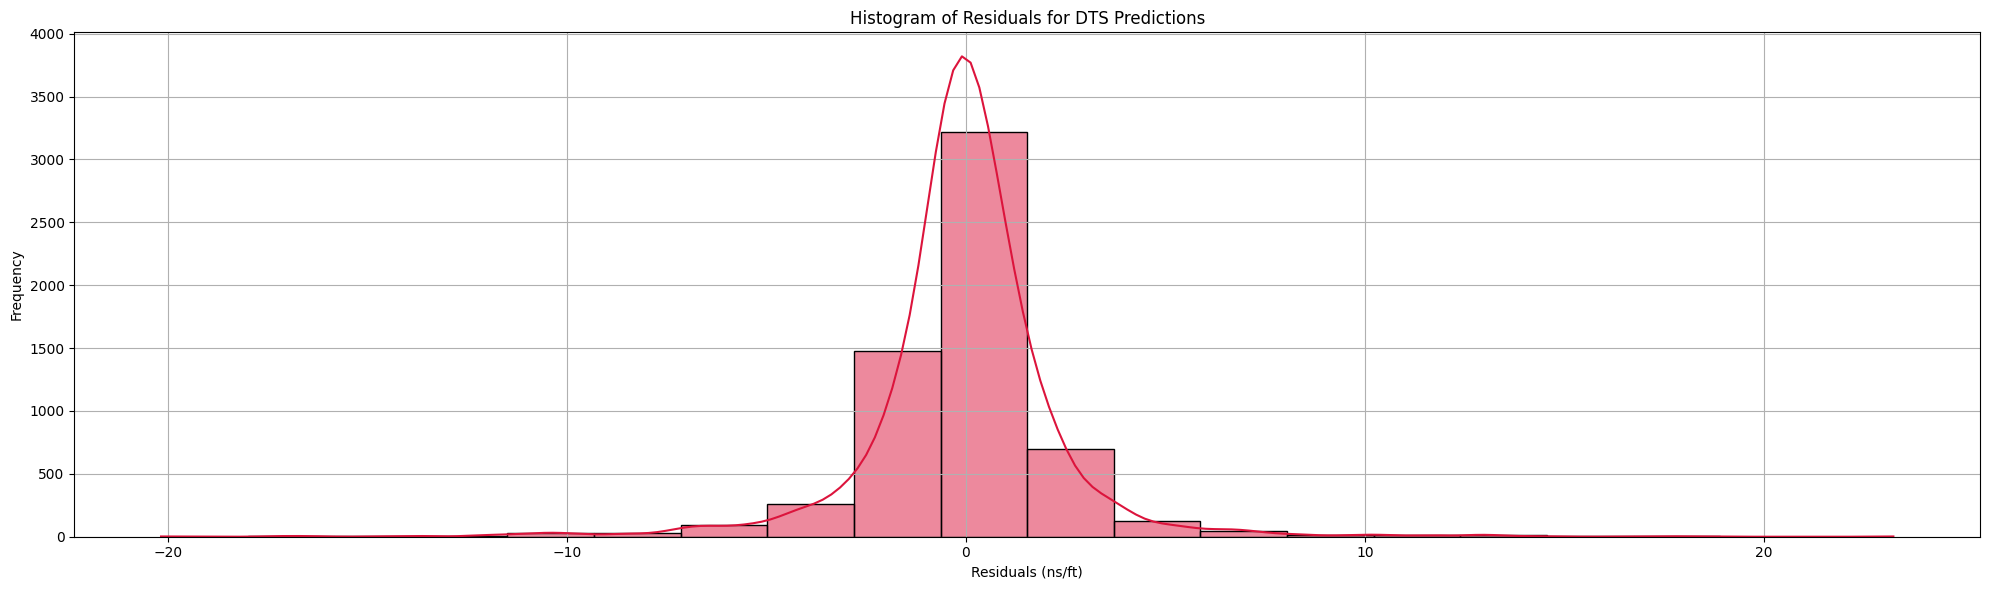

In [42]:
plt.figure(figsize=(20, 6))
sns.histplot(residuals, bins=20, kde=True, color='crimson')
plt.xlabel('Residuals (ns/ft)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals for DTS Predictions')
plt.grid(True)
plt.tight_layout()
plt.show()

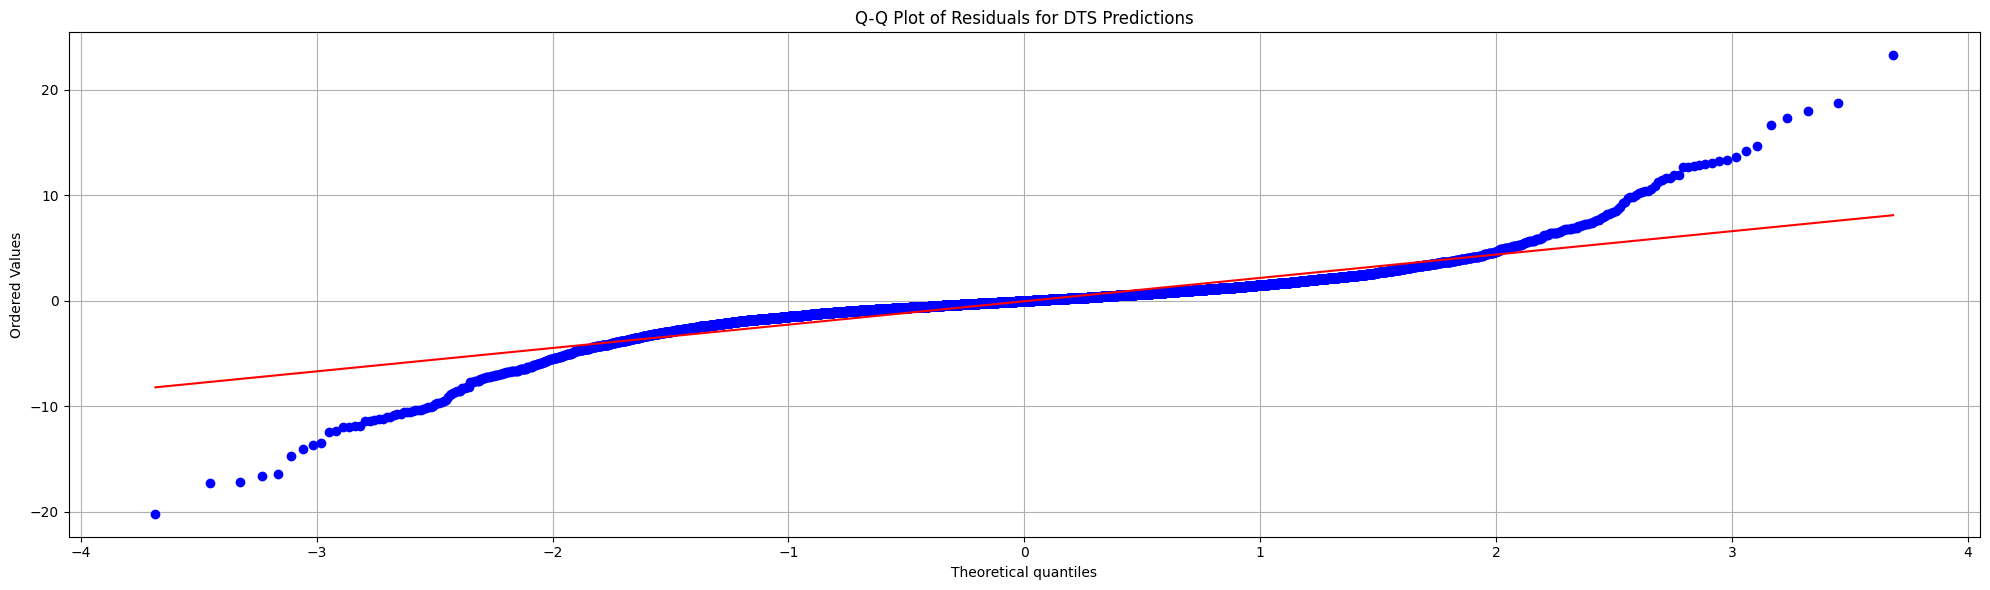

In [43]:
plt.figure(figsize=(20, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals for DTS Predictions')
plt.grid(True)
plt.tight_layout()
plt.show()

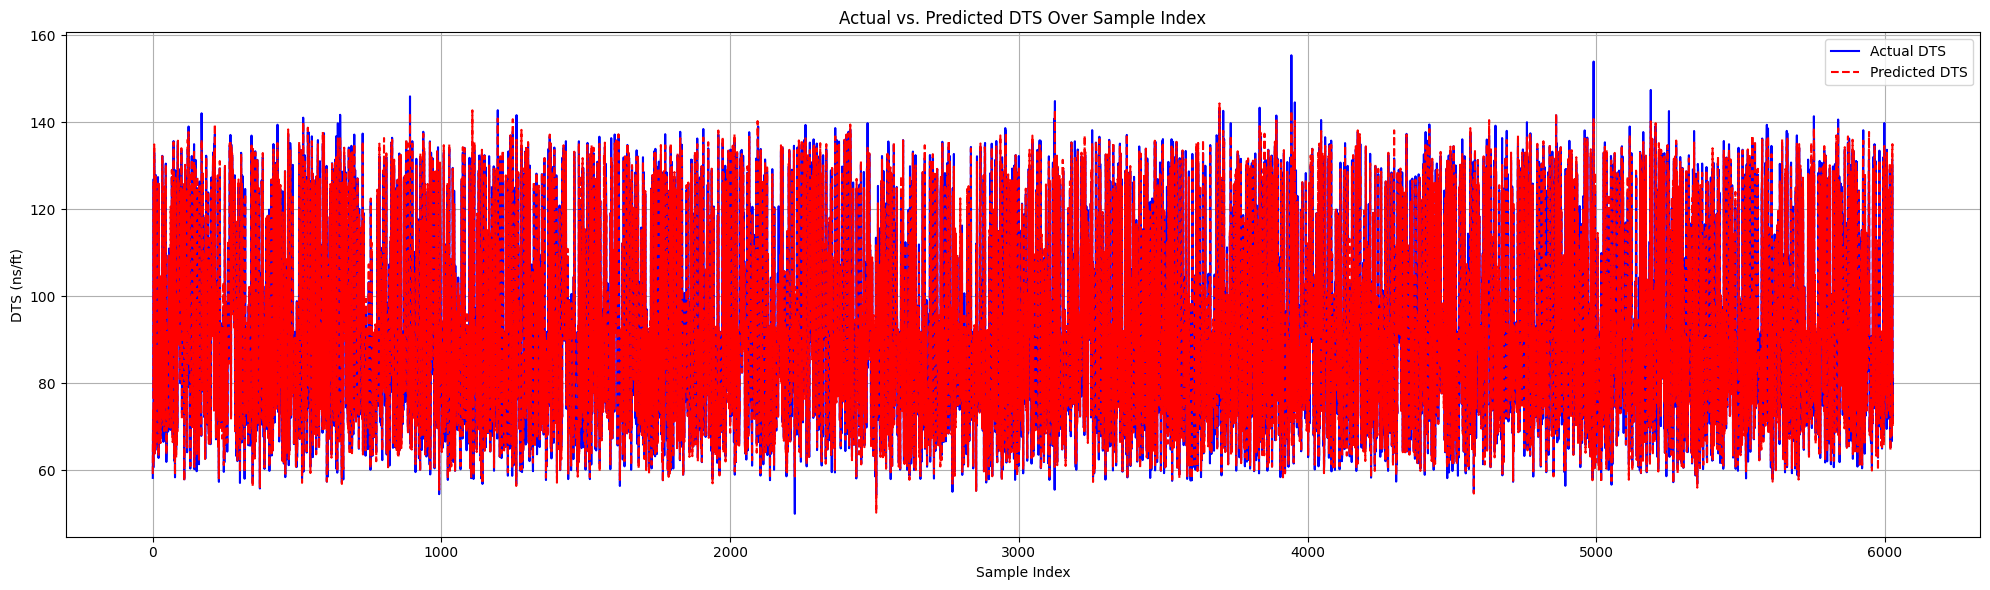

In [44]:
plt.figure(figsize=(20, 6))
plt.plot(range(len(y_test)), y_test, 'b-', label='Actual DTS')
plt.plot(range(len(y_pred_dts)), y_pred_dts, 'r--', label='Predicted DTS')
plt.xlabel('Sample Index')
plt.ylabel('DTS (ns/ft)')
plt.title('Actual vs. Predicted DTS Over Sample Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

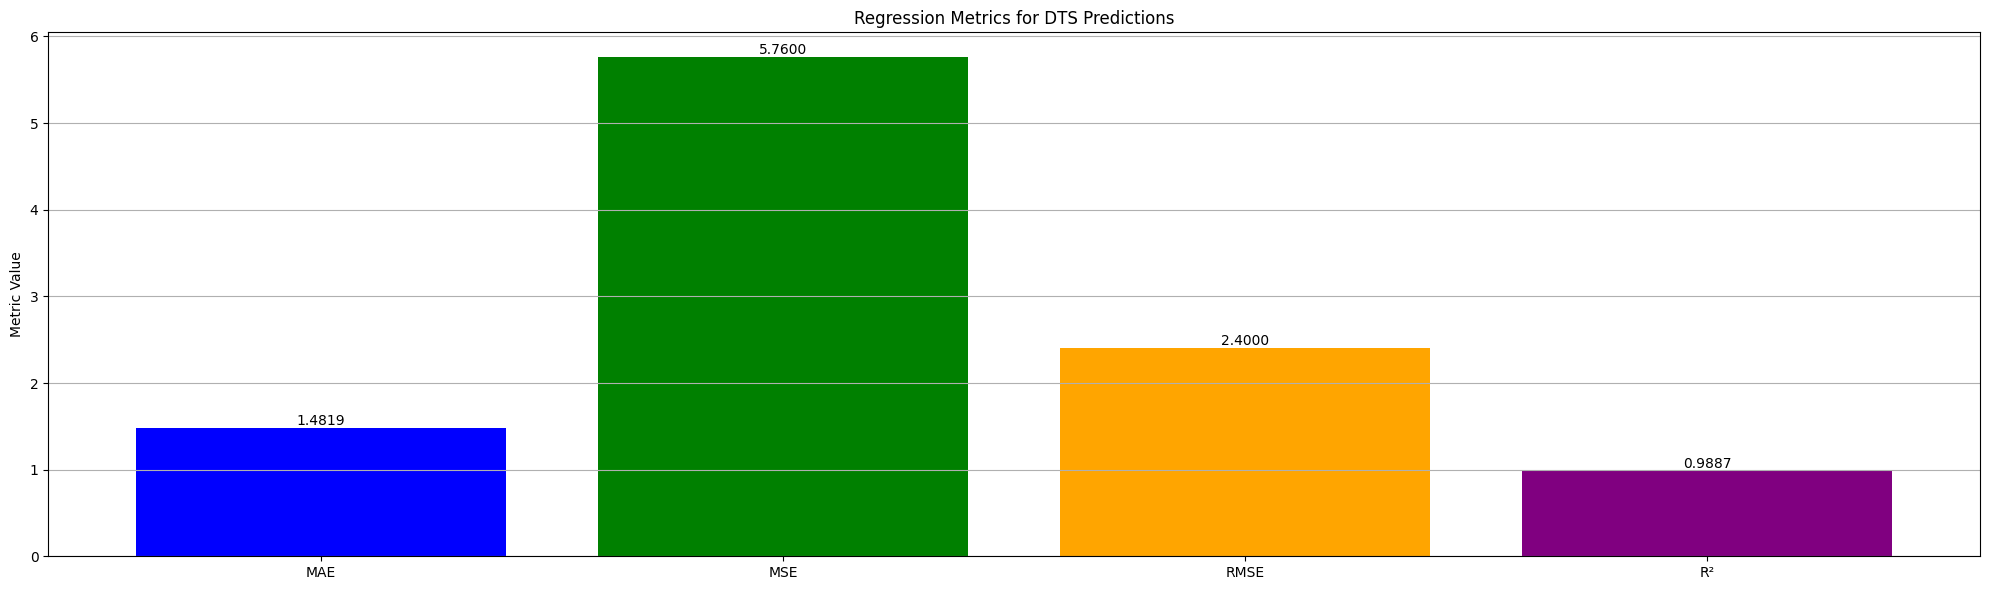

In [45]:
metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}
plt.figure(figsize=(20, 6))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'orange', 'purple'])
plt.ylabel('Metric Value')
plt.title('Regression Metrics for DTS Predictions')
for i, v in enumerate(metrics.values()):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

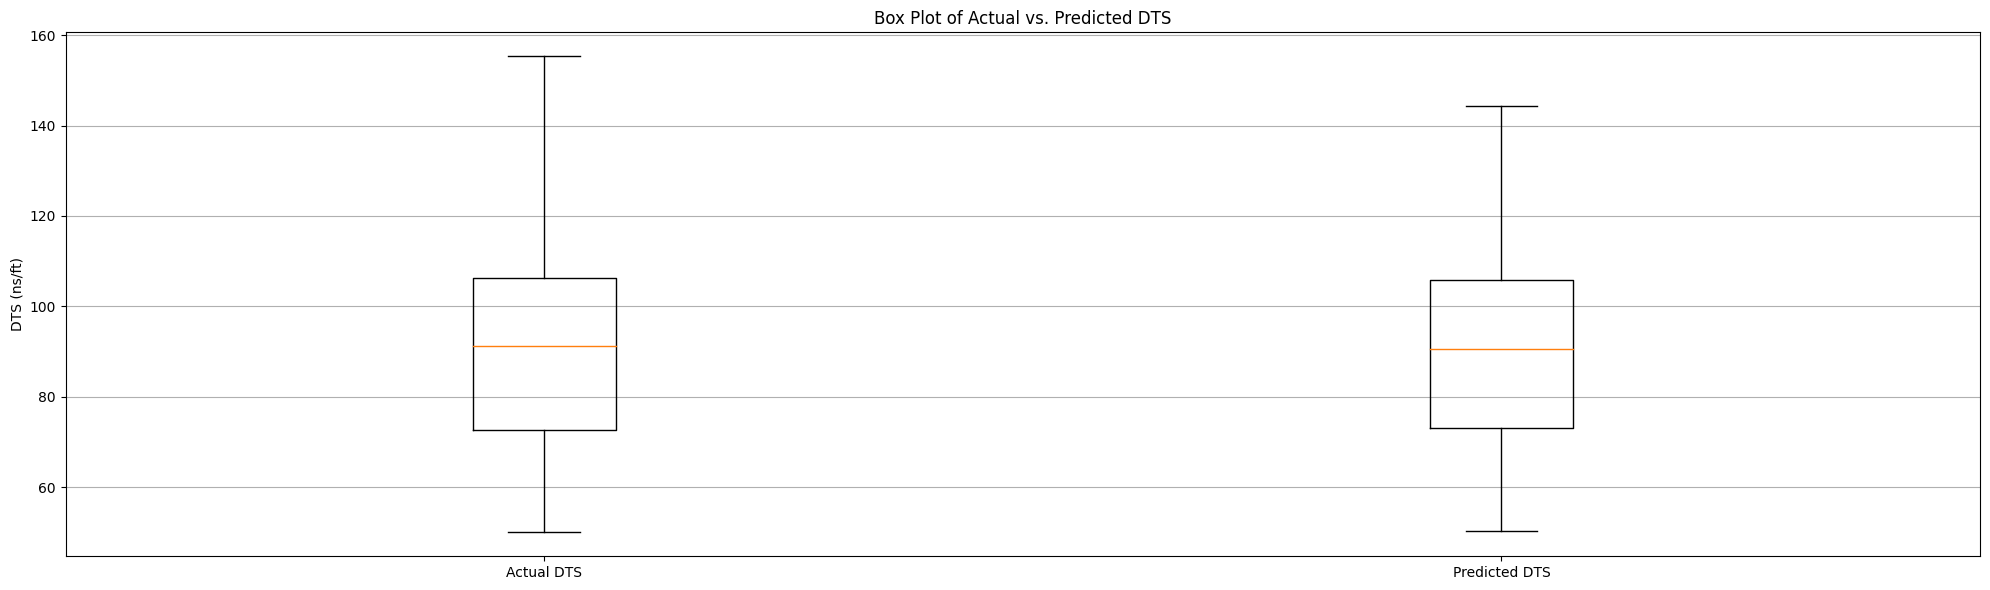

In [46]:
plt.figure(figsize=(20, 6))
plt.boxplot([y_test, y_pred_dts], labels=['Actual DTS', 'Predicted DTS'])
plt.ylabel('DTS (ns/ft)')
plt.title('Box Plot of Actual vs. Predicted DTS')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


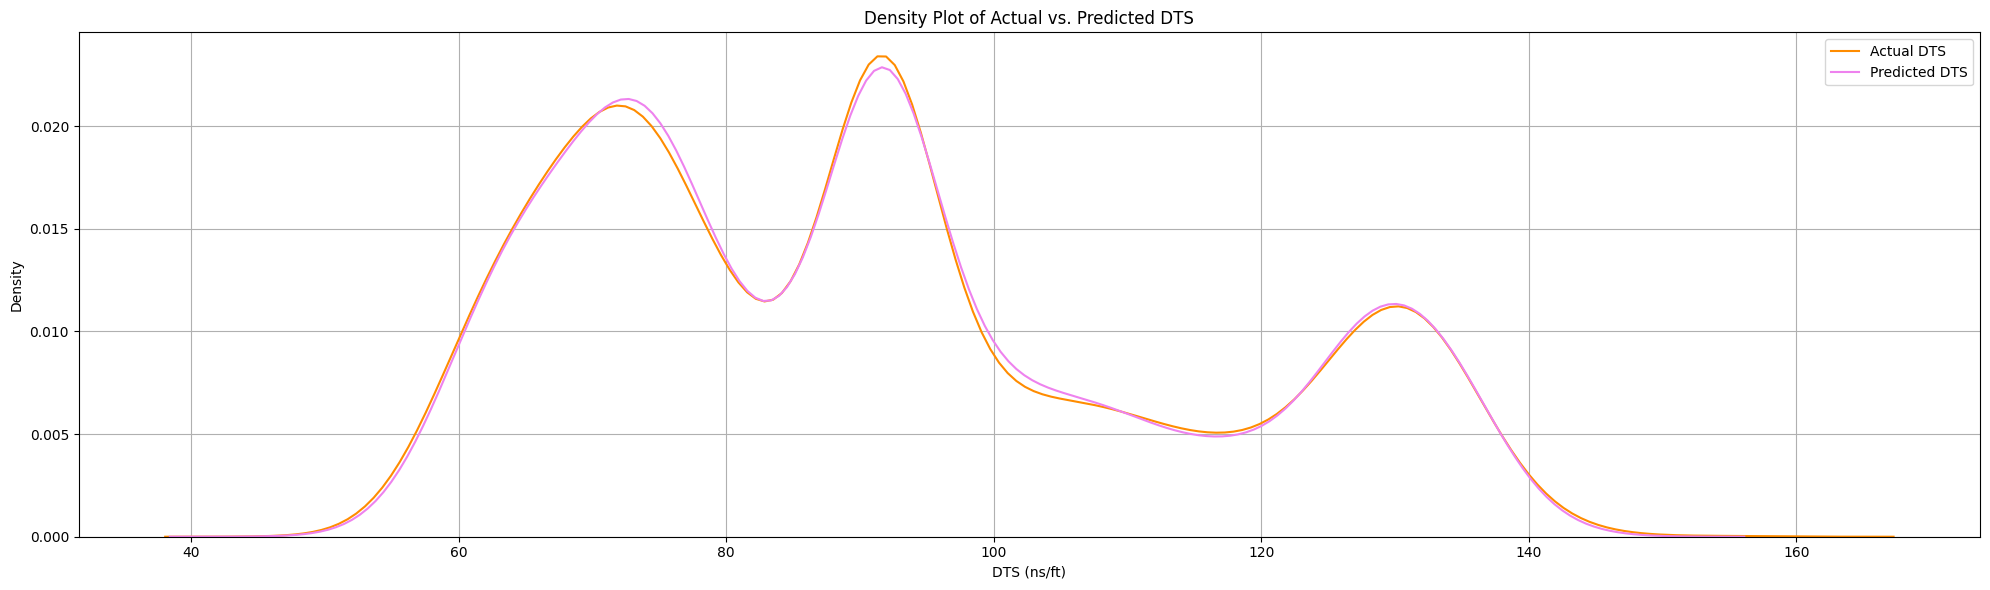

In [47]:
plt.figure(figsize=(20, 6))
sns.kdeplot(y_test, label='Actual DTS', color='darkorange')
sns.kdeplot(y_pred_dts, label='Predicted DTS', color='violet')
plt.xlabel('DTS (ns/ft)')
plt.ylabel('Density')
plt.title('Density Plot of Actual vs. Predicted DTS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
fig = px.scatter(x=y_test, y=y_pred_dts, labels={'x': 'Actual DTS (ns/ft)', 'y': 'Predicted DTS (ns/ft)'},
                 title='Interactive Predicted vs. Actual DTS')
fig.add_trace(go.Scatter(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()],
                         mode='lines', name='Perfect Prediction', line=dict(color='red', dash='dash')))
fig.show()

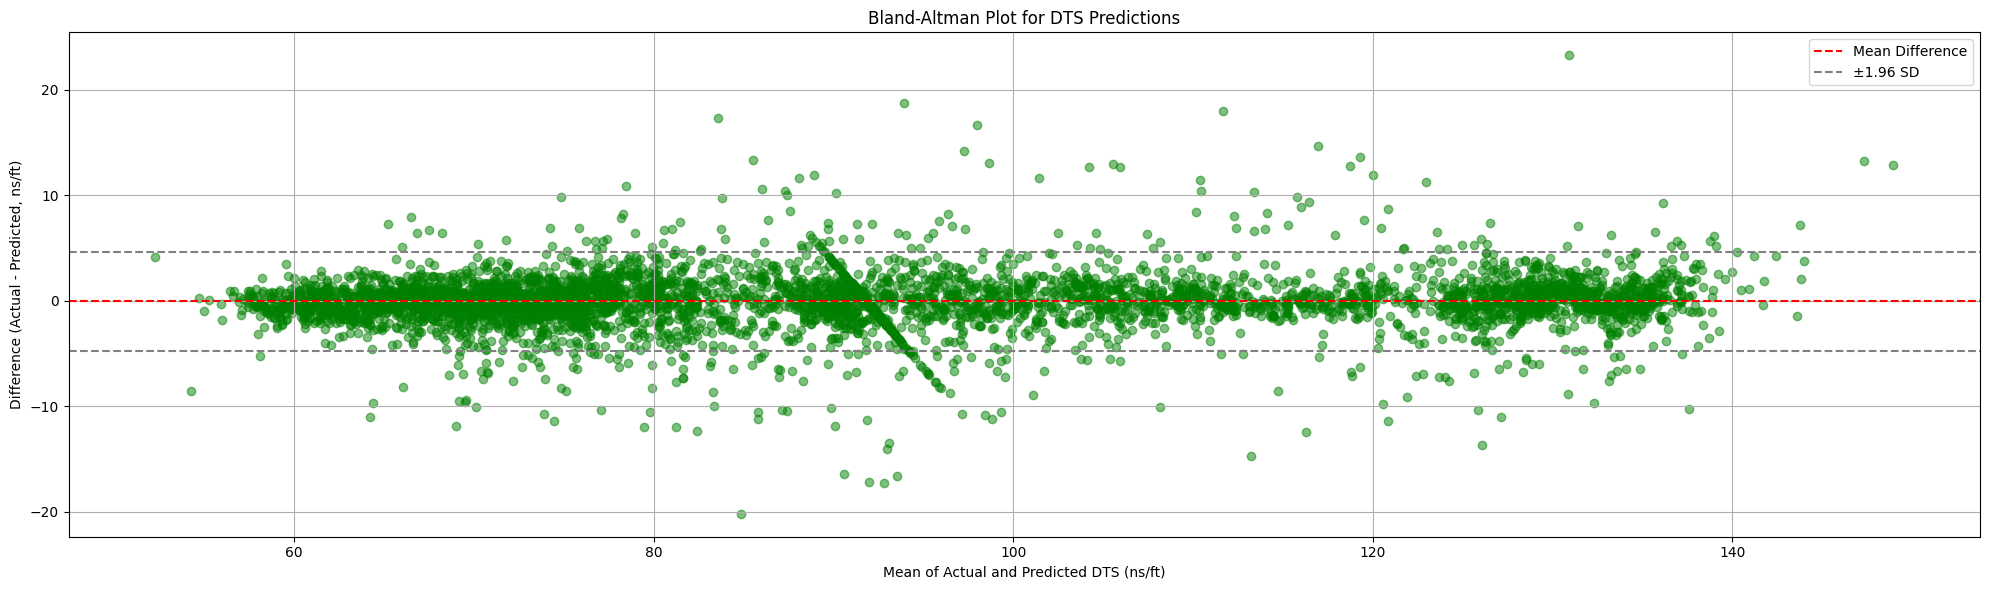

In [49]:
mean_dts = (y_test + y_pred_dts) / 2
diff_dts = y_test - y_pred_dts
plt.figure(figsize=(20, 6))
plt.scatter(mean_dts, diff_dts, color='green', alpha=0.5)
plt.axhline(np.mean(diff_dts), color='red', linestyle='--', label='Mean Difference')
plt.axhline(np.mean(diff_dts) + 1.96 * np.std(diff_dts), color='gray', linestyle='--', label='±1.96 SD')
plt.axhline(np.mean(diff_dts) - 1.96 * np.std(diff_dts), color='gray', linestyle='--')
plt.xlabel('Mean of Actual and Predicted DTS (ns/ft)')
plt.ylabel('Difference (Actual - Predicted, ns/ft)')
plt.title('Bland-Altman Plot for DTS Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
test_df = X_test.copy()
test_df["DTS"]=y_pred_dts
test_df["DTC"]=y_pred_dtc

In [51]:
test_df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,Vp_Vs,DTS,DTC
23412,8.5781,0.0539,4.7431,11.5877,11.7818,0.0532,2.6280,1.848721,59.111876,59.111876
15777,6.6262,0.1320,14.4217,1.9555,1.8155,7.7643,2.4887,1.867000,74.105444,74.105444
24453,8.5781,0.0632,8.1797,9.6486,8.6392,0.0522,2.5975,1.805108,61.157818,61.157818
6328,9.0238,0.4493,74.8905,0.7934,0.7832,3.5013,2.3095,1.423619,126.229389,126.229389
29248,8.6719,0.1665,33.2869,0.9487,1.0523,0.0482,2.4320,1.749810,76.775701,76.775701


In [52]:
test_df.to_csv('actual_df.csv', index=False)

Combined R2 score: 0.98874
DTC R2: 0.98874
DTS R2: 0.98874


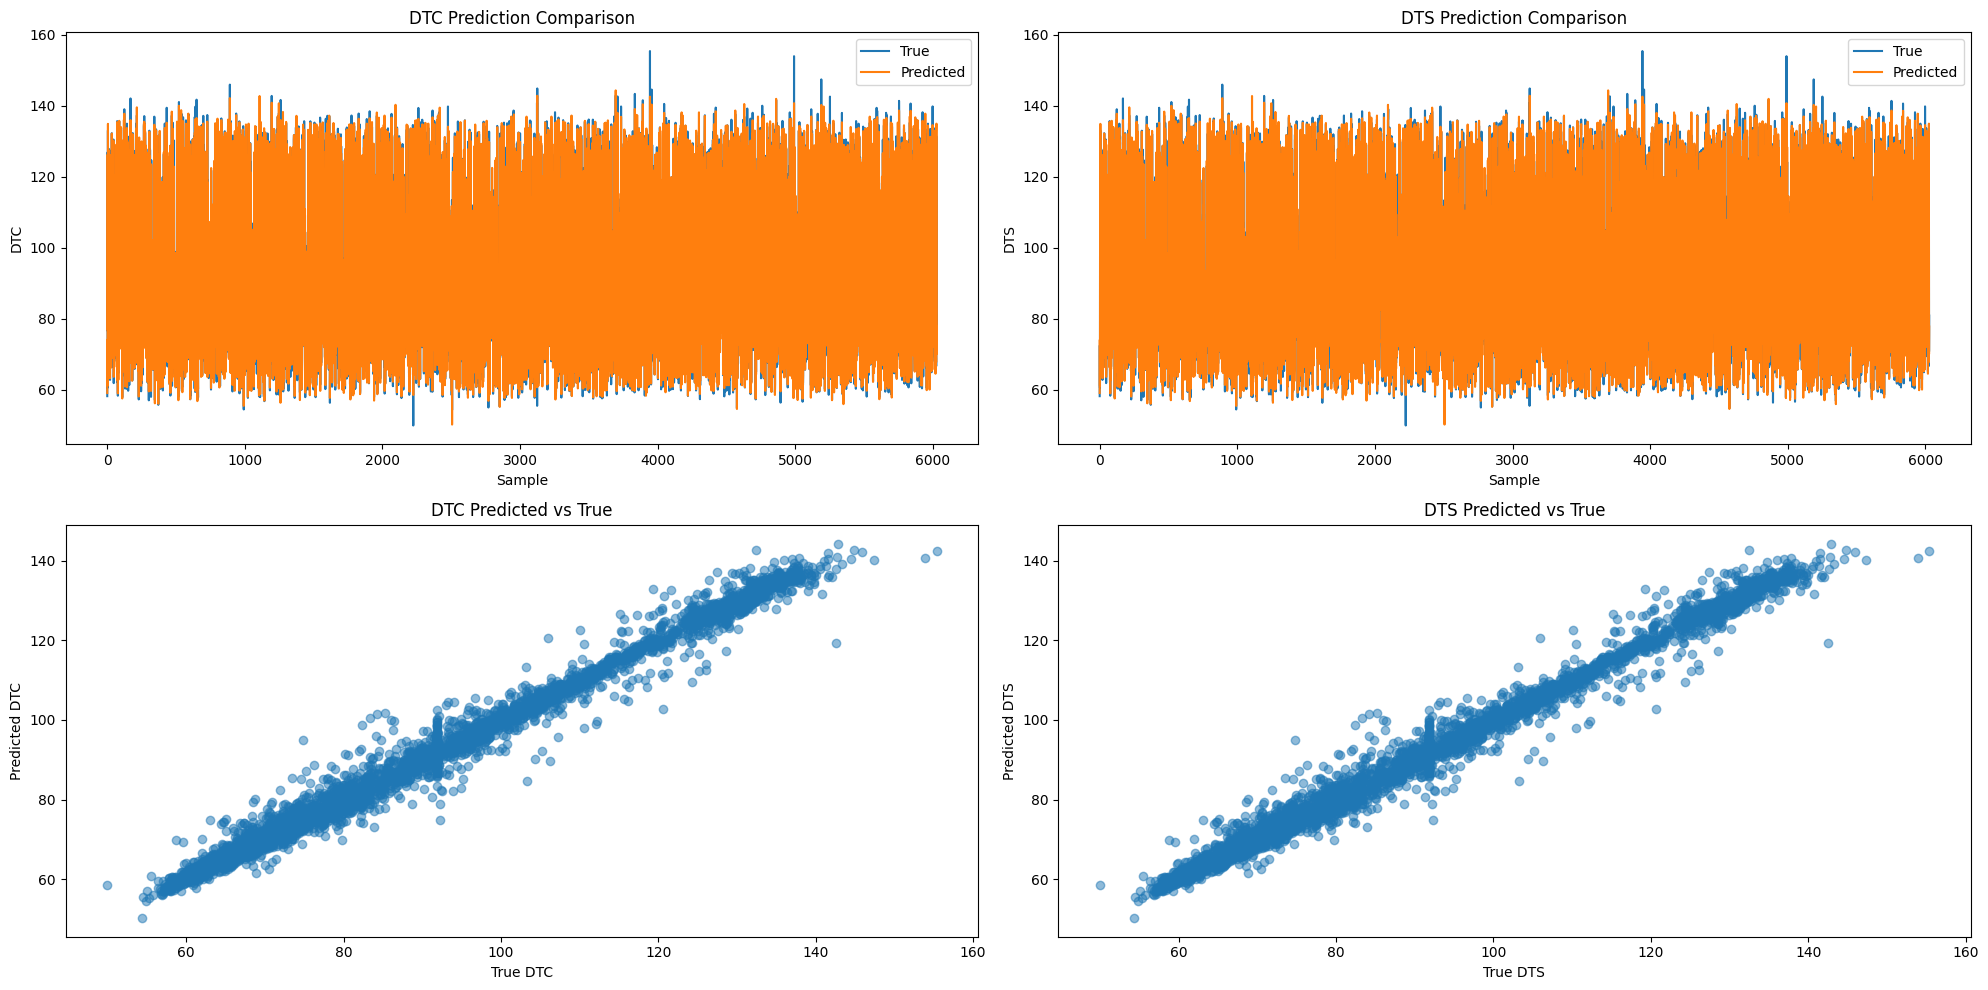

In [53]:
def result_plot(y_predict, y_real):
    print('Combined R2 score:', '{:.5f}'.format(r2_score(y_real, y_predict)))

    dtc_real = y_real[:, 0]
    dtc_pred = y_predict[:, 0]
    dts_real = y_real[:, 1]
    dts_pred = y_predict[:, 1]

    print('DTC R2:', '{:.5f}'.format(r2_score(dtc_real, dtc_pred)))
    print('DTS R2:', '{:.5f}'.format(r2_score(dts_real, dts_pred)))

    fig, axs = plt.subplots(2, 2, figsize=(20, 10))

    axs[0, 0].plot(dtc_real, label='True')
    axs[0, 0].plot(dtc_pred, label='Predicted')
    axs[0, 0].set_title('DTC Prediction Comparison')
    axs[0, 0].set_xlabel('Sample')
    axs[0, 0].set_ylabel('DTC')
    axs[0, 0].legend()

    axs[0, 1].plot(dts_real, label='True')
    axs[0, 1].plot(dts_pred, label='Predicted')
    axs[0, 1].set_title('DTS Prediction Comparison')
    axs[0, 1].set_xlabel('Sample')
    axs[0, 1].set_ylabel('DTS')
    axs[0, 1].legend()

    axs[1, 0].scatter(dtc_real, dtc_pred, alpha=0.5)
    axs[1, 0].set_title('DTC Predicted vs True')
    axs[1, 0].set_xlabel('True DTC')
    axs[1, 0].set_ylabel('Predicted DTC')

    axs[1, 1].scatter(dts_real, dts_pred, alpha=0.5)
    axs[1, 1].set_title('DTS Predicted vs True')
    axs[1, 1].set_xlabel('True DTS')
    axs[1, 1].set_ylabel('Predicted DTS')

    plt.tight_layout()
    plt.show()

y_test_dtc = y_test_dtc.to_numpy() if not isinstance(y_test_dtc, np.ndarray) else y_test_dtc
y_test = y_test.to_numpy() if not isinstance(y_test, np.ndarray) else y_test
y_pred_dtc = np.array(y_pred_dtc)
y_pred_dts = np.array(y_pred_dts)

y_real_combined = np.column_stack((y_test_dtc, y_test))
y_pred_combined = np.column_stack((y_pred_dtc, y_pred_dts))

result_plot(y_pred_combined, y_real_combined)


RMSE of test data (DTC): 2.40
RMSE of test data (DTS): 2.40
Overall RMSE = 2.40


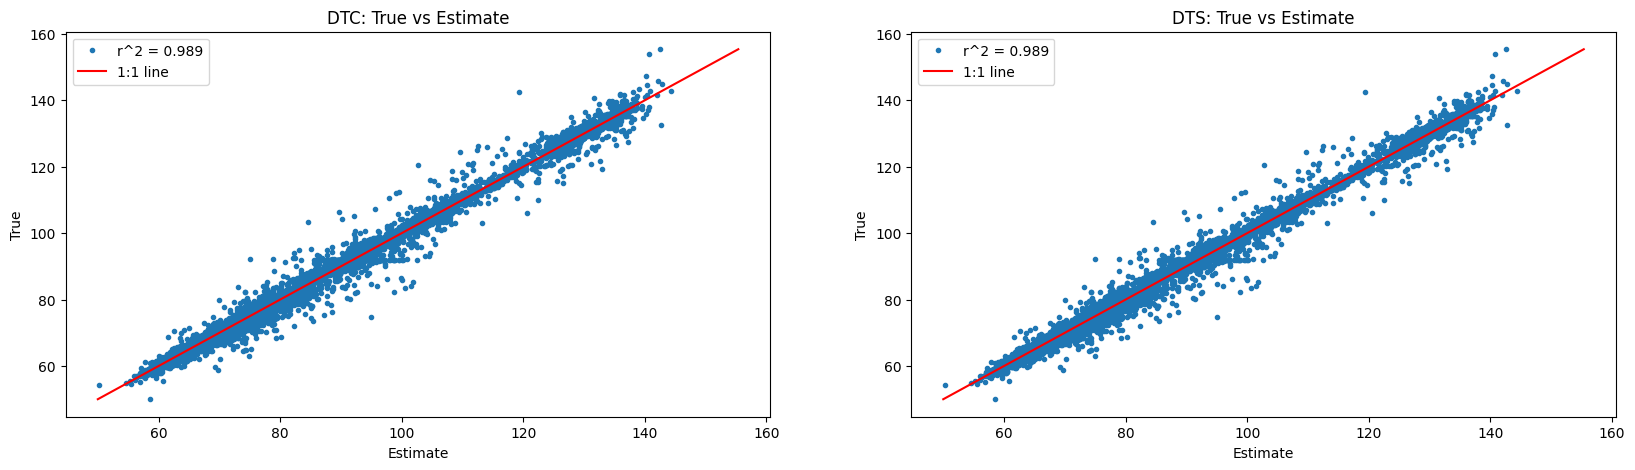

In [54]:
def plot_results(preds, reals):
    plt.figure(figsize=(20, 5))

    for i, label in enumerate(['DTC', 'DTS']):
        plt.subplot(1, 2, i+1)
        plt.plot(preds[:, i], reals[:, i], '.', label=f'r^2 = {r2_score(reals[:, i], preds[:, i]):.3f}')
        plt.plot([reals[:, i].min(), reals[:, i].max()],
                 [reals[:, i].min(), reals[:, i].max()], 'r', label='1:1 line')
        plt.title(f'{label}: True vs Estimate')
        plt.xlabel('Estimate')
        plt.ylabel('True')
        plt.legend()

    MSE_0 = mean_squared_error(reals[:, 0], preds[:, 0])
    RMSE_0 = np.sqrt(MSE_0)
    MSE_1 = mean_squared_error(reals[:, 1], preds[:, 1])
    RMSE_1 = np.sqrt(MSE_1)

    print(f'RMSE of test data (DTC): {RMSE_0:.2f}')
    print(f'RMSE of test data (DTS): {RMSE_1:.2f}')
    print(f'Overall RMSE = {np.sqrt((MSE_0 + MSE_1) / 2):.2f}')


plot_results(y_pred_combined, y_real_combined)


In [55]:
from pycaret.regression import *

In [56]:
df_dts.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264
1,8.654281,0.683437,42.5053,16.953912,14.492077,5.173227,2.393818,127.8347,318.7825,2.493709
2,8.654281,0.683437,43.1548,16.953912,14.492077,5.173227,2.393818,127.2307,317.3323,2.494149
3,8.654281,0.683437,43.2410,16.953912,14.492077,5.173227,2.393818,126.2917,313.6486,2.483525
4,8.654281,0.683437,40.3218,16.953912,14.492077,5.173227,2.393818,125.3985,307.8903,2.455295


In [57]:
df_dtc.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264
1,8.654281,0.683437,42.5053,16.953912,14.492077,5.173227,2.393818,127.8347,318.7825,2.493709
2,8.654281,0.683437,43.1548,16.953912,14.492077,5.173227,2.393818,127.2307,317.3323,2.494149
3,8.654281,0.683437,43.2410,16.953912,14.492077,5.173227,2.393818,126.2917,313.6486,2.483525
4,8.654281,0.683437,40.3218,16.953912,14.492077,5.173227,2.393818,125.3985,307.8903,2.455295


In [58]:
df_dts_pycaret= df_dts.drop(['DTC'],axis=1)

In [59]:
from pycaret.regression import RegressionExperiment
s=RegressionExperiment()
s.setup(data= df_dts_pycaret, target= 'DTS',normalize= True,remove_outliers=True,profile=False)

,Description,Value
0,Session id,6259
1,Target,DTS
2,Target type,Regression
3,Original data shape,"(30143, 9)"
4,Transformed data shape,"(29088, 9)"
5,Transformed train set shape,"(20045, 9)"
6,Transformed test set shape,"(9043, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [60]:
# functional API
best = s.compare_models()



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,2.8397,51.3860,6.9911,0.9908,0.0316,0.0148,18.8710
xgboost,Extreme Gradient Boosting,3.6256,67.5470,7.7611,0.9880,0.0355,0.0195,0.6720
catboost,CatBoost Regressor,3.8072,72.1985,8.1985,0.9872,0.0361,0.0202,8.3490
et,Extra Trees Regressor,2.6225,73.6246,8.1188,0.9869,0.0325,0.0126,5.0310
gbr,Gradient Boosting Regressor,5.3904,89.5443,9.3841,0.9839,0.0461,0.0299,5.3190
lightgbm,Light Gradient Boosting Machine,4.1384,91.4748,9.2862,0.9837,0.0408,0.0220,3.2010
dt,Decision Tree Regressor,3.8359,125.1768,10.9117,0.9777,0.0473,0.0193,0.6690
knn,K Neighbors Regressor,4.3553,217.0719,13.7016,0.9616,0.0612,0.0214,0.4490
ada,AdaBoost Regressor,10.4320,240.2532,15.4281,0.9570,0.0869,0.0638,1.9290
omp,Orthogonal Matching Pursuit,37.1460,2036.6505,45.1258,0.6347,0.2494,0.2154,0.3430


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

In [61]:
print(best)

RandomForestRegressor(n_jobs=-1, random_state=6259)


In [62]:
# functional API
s.evaluate_model(best)



interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

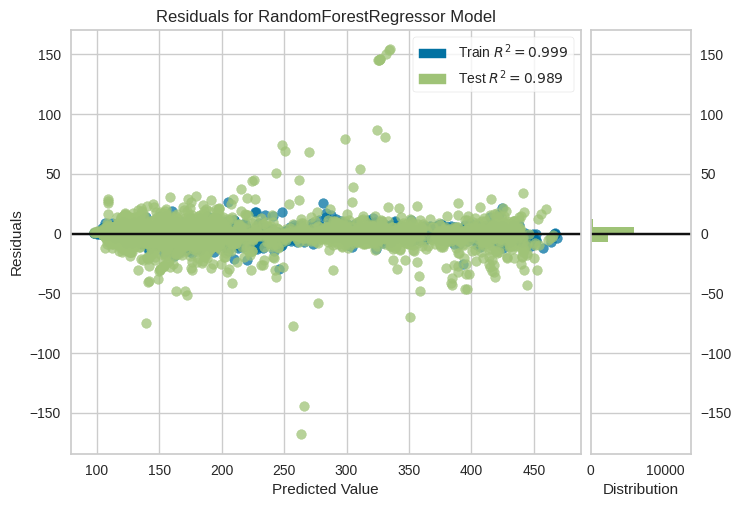

In [63]:
# functional API
s.plot_model(best, plot = 'residuals')



In [64]:
# plot_types = [
#     'residuals', 'error', 'cooks', 'rfe', 'learning', 'validation',
#     'vc', 'feature', 'parameter', 'manifold', 'class_report', 'calibration',
#     'threshold', 'gain', 'lift'
# ]

# for plot in plot_types:
#     print(f"Showing plot: {plot}")
#     s.plot_model(best, plot=plot)


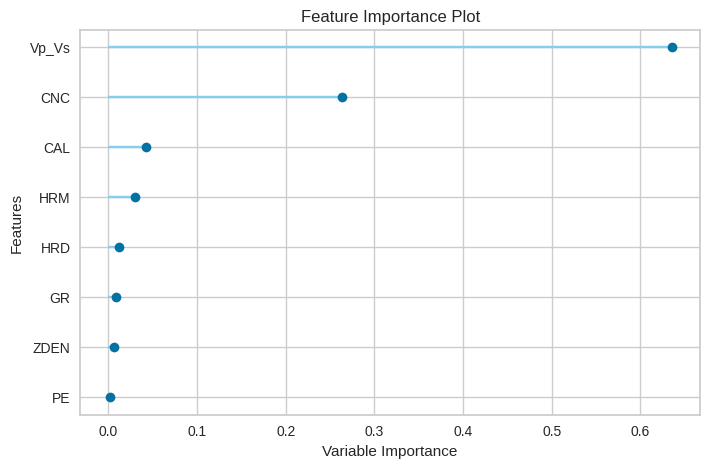

In [65]:
# functional API
s.plot_model(best, plot = 'feature')



In [66]:
# functional API
s.predict_model(best)



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.6565,57.1152,7.5575,0.9894,0.0343,0.0145


,CAL,CNC,GR,HRD,HRM,PE,ZDEN,Vp_Vs,DTS,prediction_label
14489,6.5355,0.1994,10.017100,1.2756,1.225100,7.7117,2.3364,1.959030,163.642105,173.098840
2682,11.1543,0.5600,68.152298,0.8994,0.872800,11.7241,2.2705,2.660746,328.241608,329.158067
24250,8.5781,0.1111,16.969700,3.0164,3.227300,0.0433,2.5413,1.872857,131.546707,132.018332
16774,6.4704,0.1646,26.139999,2.3773,2.169800,8.4337,2.5745,1.919509,138.751694,144.661563
29004,8.6719,0.0833,46.235500,5.0481,7.582000,0.0491,2.6237,1.737989,108.641701,111.760769
...,...,...,...,...,...,...,...,...,...,...
29979,8.7031,0.1986,115.731796,2.3371,2.243000,0.0592,2.6264,1.702631,128.303101,128.232527
19743,6.4903,0.2390,89.320396,1.5456,1.539600,14.1238,2.5961,1.933806,150.925598,164.234326
2851,13.2545,0.5617,65.187500,0.7592,0.744600,6.0274,2.2024,2.818932,374.058502,372.539322
21039,8.5469,0.3209,26.841600,0.5938,0.543800,0.0903,2.3498,1.865511,169.214203,181.303262


In [67]:
# functional API
predictions = s.predict_model(best, data=df_dts_pycaret)
predictions.head()



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.6774,37.0659,6.0882,0.9933,0.0259,0.0088


,CAL,CNC,GR,HRD,HRM,PE,ZDEN,Vp_Vs,DTS,prediction_label
0,8.654281,0.683437,41.469898,16.953913,14.492077,5.173227,2.393818,2.491264,319.065399,320.823626
1,8.654281,0.683437,42.505299,16.953913,14.492077,5.173227,2.393818,2.493709,318.782501,321.972842
2,8.654281,0.683437,43.154800,16.953913,14.492077,5.173227,2.393818,2.494149,317.332306,322.096545
3,8.654281,0.683437,43.241001,16.953913,14.492077,5.173227,2.393818,2.483525,313.648590,319.830793
4,8.654281,0.683437,40.321800,16.953913,14.492077,5.173227,2.393818,2.455295,307.890289,315.297104


In [68]:

# functional API
s.save_model(best, 'my_best_pipeline')



Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['CAL', 'CNC', 'GR', 'HRD', 'HRM',
                                              'PE', 'ZDEN', 'Vp_Vs'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_outliers',
                  TransformerWrapper(transformer=RemoveOutliers(random_state=6259))),
                 ('normalize', TransformerWrapper(transformer=StandardScaler())),
                 ('trained_model',
                  RandomForestRegressor(n_jobs=-1, random_state=6259))]),
 'my_best_pipeline.pkl')

In [69]:
# functional API
loaded_model = load_model('my_best_pipeline')
print(loaded_model)


Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['CAL', 'CNC', 'GR', 'HRD', 'HRM',
                                             'PE', 'ZDEN', 'Vp_Vs'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('remove_outliers',
                 TransformerWrapper(transformer=RemoveOutliers(random_state=6259))),
                ('normalize', TransformerWrapper(transformer=StandardScaler())),
                ('trained_model',
                 RandomForestRegressor(n_jobs=-1, random_state=6259))])


In [70]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(model_dts)
new_test=test_df.copy()

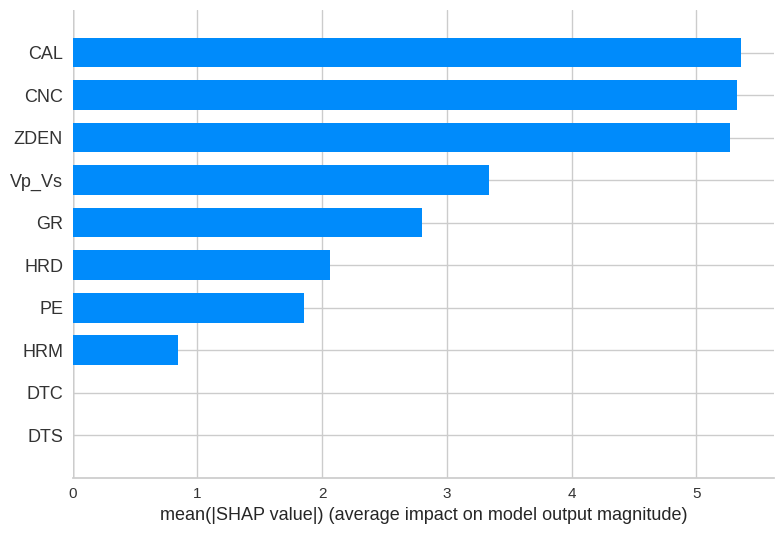

In [71]:
shap_values = explainer.shap_values(new_test)
shap.summary_plot(shap_values, new_test, plot_type="bar")

In [72]:
def make_dwt_vars_cA(wells_df, logs, levels, wavelet):
    # Initialize the wavelet object with the chosen wavelet type
    wave = pywt.Wavelet(wavelet)

    temp_dfs = []  # List to collect temporary DataFrames instead of using append on DataFrame

    # Iterate over keys in wells_df (same as your original logic)
    for key in wells_df.keys():
        depth = wells_df['Depth']  # Extract depth column

        # Create a temporary DataFrame with Depth column to store coefficients
        temp_df = pd.DataFrame()
        temp_df['Depth'] = depth

        # Loop over each log to process
        for log in logs:
            temp_data = wells_df[log]  # Extract log data

            # Loop over each level of decomposition
            for i in levels:
                # Perform wavelet decomposition to get coefficients
                cA_cD = pywt.wavedec(temp_data, wave, level=i, mode='symmetric')
                cA = cA_cD[0]  # Approximate coefficients (cA)

                # Create new depth values to match the length of cA coefficients
                new_depth = np.linspace(min(depth), max(depth), len(cA))

                # Interpolate the cA values back to original depth points using nearest neighbor
                fA = interp1d(new_depth, cA, kind='nearest')

                # Add interpolated cA values as new columns to temp_df
                temp_df[log + '_cA_level_' + str(i)] = fA(depth)

        # Append the temporary DataFrame for the current key to the list
        temp_dfs.append(temp_df)

    # Concatenate all temporary DataFrames collected in the list into a single DataFrame
    new_df = pd.concat(temp_dfs)

    # Sort by index (optional depending on your needs)
    new_df = new_df.sort_index()

    # Drop the Depth column as it’s no longer needed in the output
    new_df = new_df.drop(['Depth'], axis=1)

    # Return the final DataFrame containing all interpolated approximate coefficients
    return new_df


In [73]:
def make_dwt_vars_cD(wells_df, logs, levels, wavelet):
    # Initialize wavelet object
    wave = pywt.Wavelet(wavelet)

    temp_dfs = []  # List to store temporary DataFrames

    grouped = wells_df  # your original variable

    for key in grouped.keys():
        depth = grouped['Depth']

        # Temporary DataFrame to store interpolated coefficients for this group
        temp_df = pd.DataFrame()
        temp_df['Depth'] = depth

        for log in logs:
            temp_data = grouped[log]

            # Perform 4-level wavelet decomposition to get cA and cD coefficients
            cA_4, cD_4, cD_3, cD_2, cD_1 = pywt.wavedec(temp_data, wave, level=4, mode='symmetric')
            dict_cD_levels = {1: cD_1, 2: cD_2, 3: cD_3, 4: cD_4}  # Map levels to detailed coeffs

            for i in levels:
                # Interpolate cD values for level i back to original depth points
                new_depth = np.linspace(min(depth), max(depth), len(dict_cD_levels[i]))
                fA = interp1d(new_depth, dict_cD_levels[i], kind='nearest')
                temp_df[log + '_cD_level_' + str(i)] = fA(depth)

        # Instead of append to DataFrame, add temp_df to list
        temp_dfs.append(temp_df)

    # Concatenate all temp DataFrames once at the end
    new_df = pd.concat(temp_dfs)
    new_df = new_df.sort_index()

    # Drop Depth column as per original function
    new_df = new_df.drop(['Depth'], axis=1)

    return new_df


In [74]:
df_wavelet= df.copy()

In [75]:
df_wavelet.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264
1,8.654281,0.683437,42.5053,16.953912,14.492077,5.173227,2.393818,127.8347,318.7825,2.493709
2,8.654281,0.683437,43.1548,16.953912,14.492077,5.173227,2.393818,127.2307,317.3323,2.494149
3,8.654281,0.683437,43.2410,16.953912,14.492077,5.173227,2.393818,126.2917,313.6486,2.483525
4,8.654281,0.683437,40.3218,16.953912,14.492077,5.173227,2.393818,125.3985,307.8903,2.455295


In [76]:
df_wavelet.shape

(30143, 10)

In [77]:
df_wavelet.isnull().sum()

,0
CAL,0
CNC,0
GR,0
HRD,0
HRM,0
PE,0
ZDEN,0
DTC,0
DTS,0
Vp_Vs,0


In [78]:
depth_train= np.linspace(500,4000,len(df_wavelet))
df_wavelet['Depth']= depth_train

In [79]:
import pywt
from scipy.interpolate import interp1d

In [80]:
#cD From wavelet db4
dwt_db4_cD_df = make_dwt_vars_cD(wells_df=df_wavelet, logs=['CNC'],levels=[1, 2, 3, 4], wavelet='db4')

# cA From wavelet db4
dwt_db4_cA_df = make_dwt_vars_cA(wells_df=df_wavelet, logs=['CNC'],levels=[1, 2, 3, 4], wavelet='db4')

In [81]:
list_df_var = [dwt_db4_cD_df, dwt_db4_cA_df]
combined_df = df_wavelet
for var_df in list_df_var:
    temp_df = var_df
    combined_df = pd.concat([combined_df,temp_df],axis=1)
combined_df.replace(to_replace=np.nan, value='-1', inplace=True)
print (combined_df.shape)
training_data=combined_df

(331573, 19)


In [82]:
training_data.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs,Depth,CNC_cD_level_1,CNC_cD_level_2,CNC_cD_level_3,CNC_cD_level_4,CNC_cA_level_1,CNC_cA_level_2,CNC_cA_level_3,CNC_cA_level_4
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748


In [83]:
df_zone1= training_data[training_data['Depth']<1000]
df_zone1.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,DTC,DTS,Vp_Vs,Depth,CNC_cD_level_1,CNC_cD_level_2,CNC_cD_level_3,CNC_cD_level_4,CNC_cA_level_1,CNC_cA_level_2,CNC_cA_level_3,CNC_cA_level_4
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748
0,8.654281,0.683437,41.4699,16.953912,14.492077,5.173227,2.393818,128.0737,319.0654,2.491264,500.0,6.852158e-17,2.081668e-17,1.370432e-16,4.163336e-17,0.966526,1.366874,1.933052,2.733748


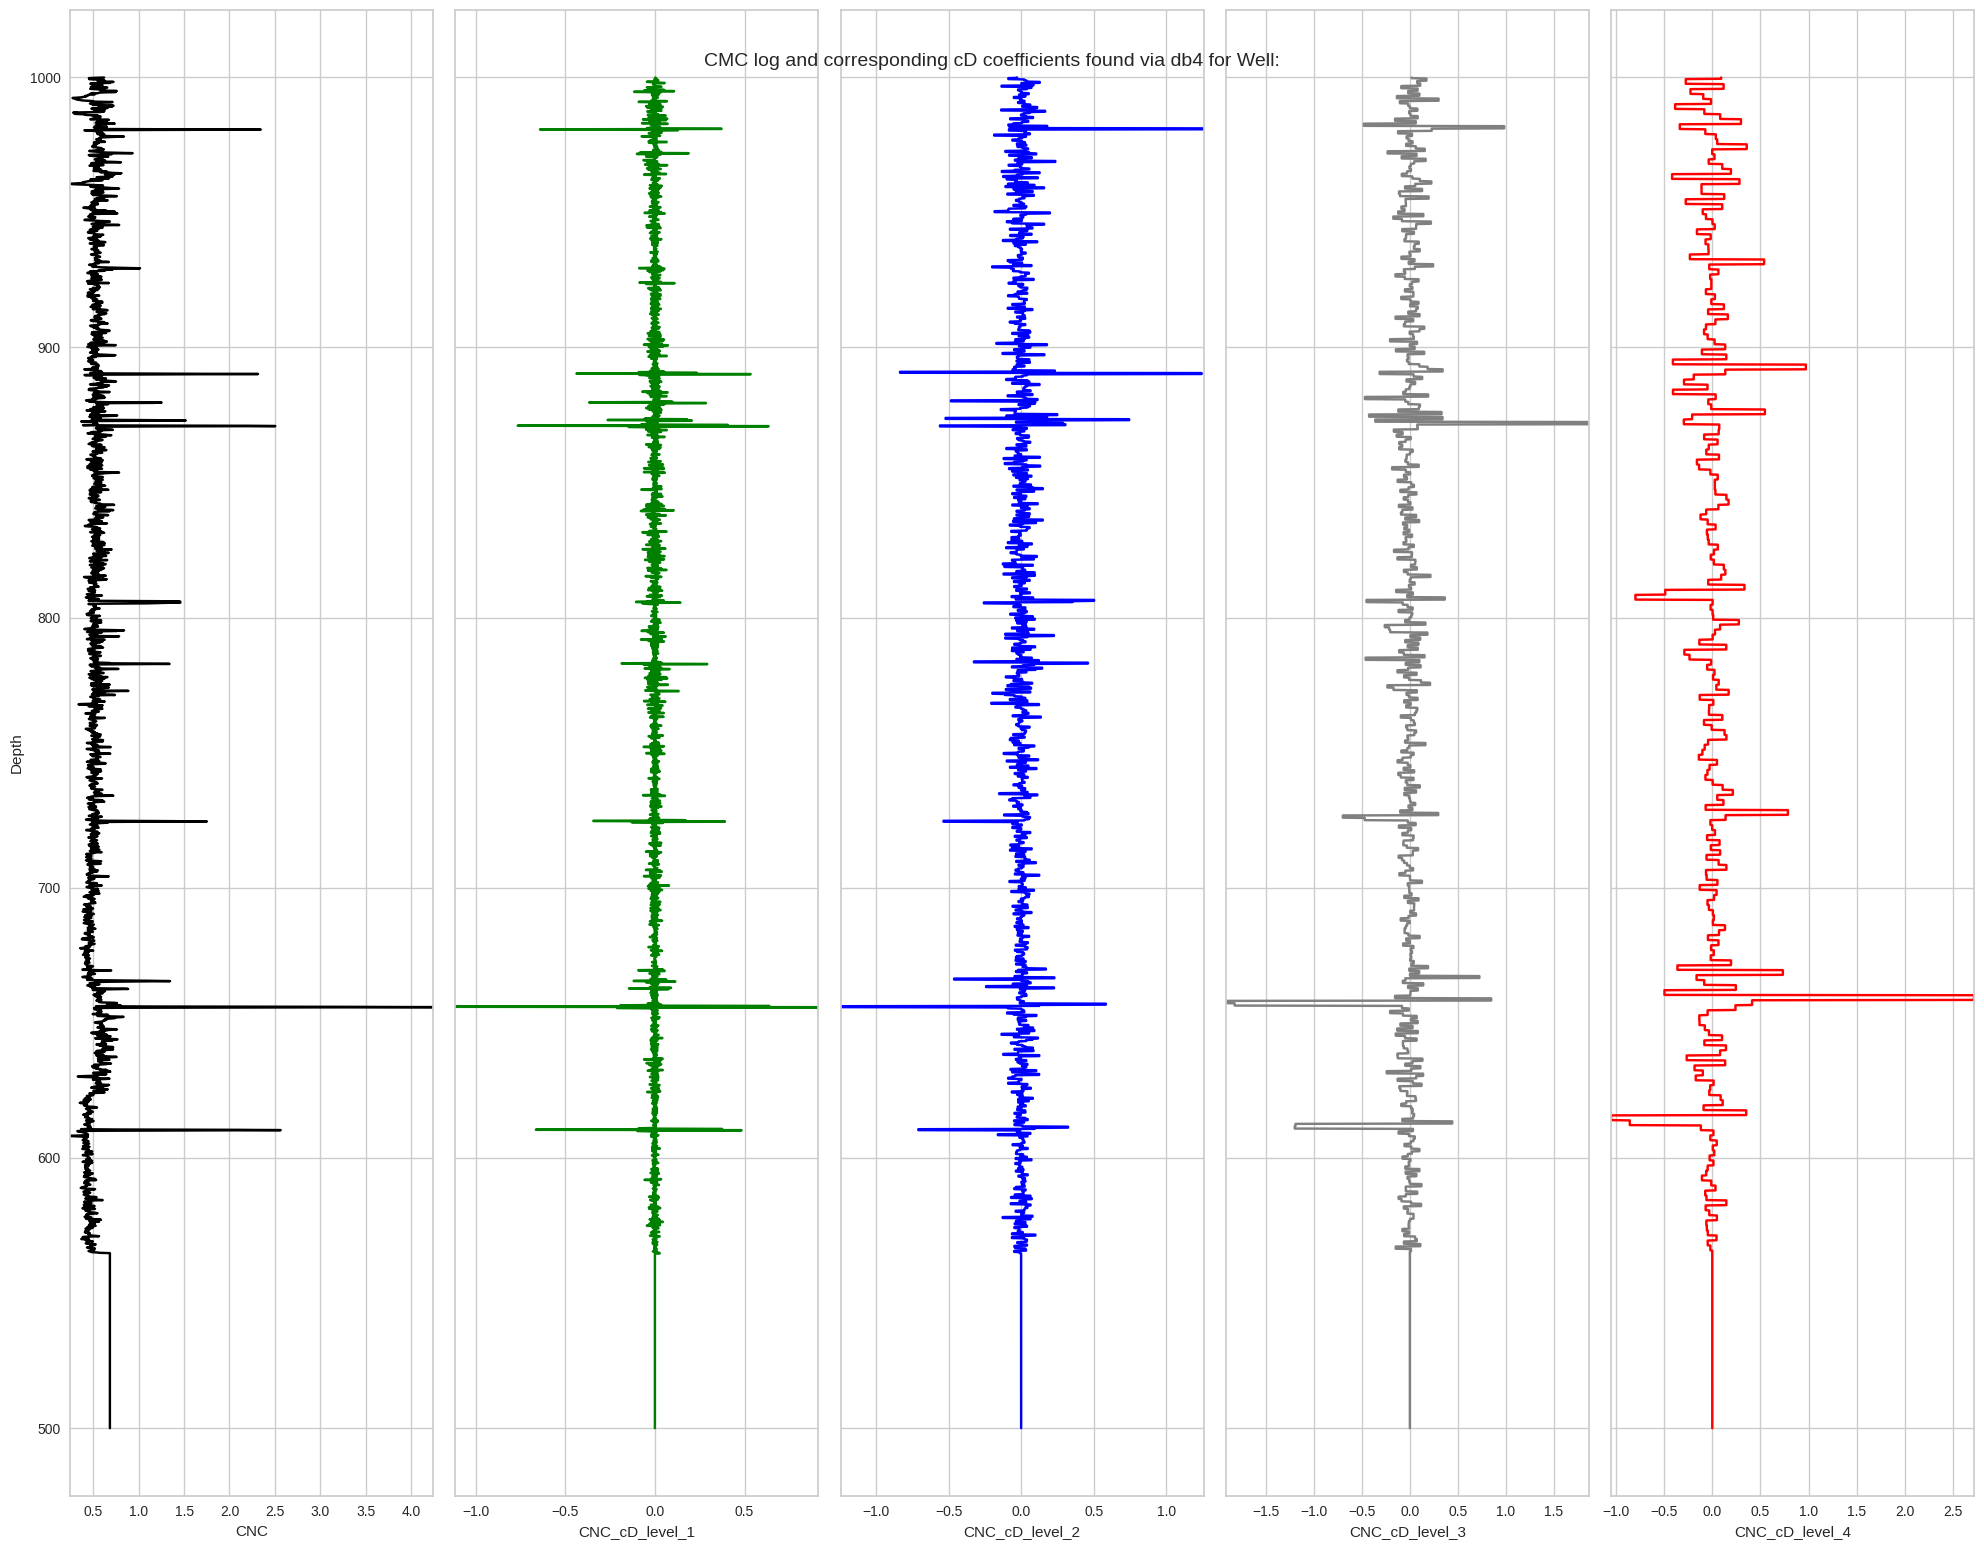

In [84]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 16))

cols = [
    ('CNC', 'black'),
    ('CNC_cD_level_1', 'green'),
    ('CNC_cD_level_2', 'blue'),
    ('CNC_cD_level_3', '0.5'),
    ('CNC_cD_level_4', 'red')
]

for i, (col, color) in enumerate(cols):
    axes[i].plot(df_zone1[col], df_zone1.Depth, '-', color=color)
    axes[i].set_xlabel(col)
    axes[i].set_xlim(df_zone1[col].min(), df_zone1[col].max())
    if i > 0:
        axes[i].set_yticklabels([])

axes[0].set_ylabel('Depth')

fig.suptitle('CMC log and corresponding cD coefficients found via db4 for Well:', fontsize=14, y=0.94)

plt.tight_layout()
plt.show()

In [85]:
df_dtc_wave=training_data.copy()

df_dtc_x_wave=df_dtc_wave.drop(columns=['DTS',"DTC"],axis=1)
df_dtc_y_wave=df_dtc_wave['DTC']

In [86]:
X_train_dtc, X_test_dtc, y_train_dtc, y_test_dtc = train_test_split(df_dtc_x_wave, df_dtc_y_wave, test_size=0.2, random_state=42)

# Initialize CatBoost Regressor
model_dtc = CatBoostRegressor(verbose=100, random_seed=42,learning_rate=0.1,iterations=1000)

# Fit model
model_dtc.fit(X_train_dtc, y_train_dtc, eval_set=(X_test_dtc, y_test_dtc), use_best_model=True)

# Optionally, predict on test set
y_pred_dtc = model_dtc.predict(X_test_dtc)

0:	learn: 20.5880781	test: 20.6108451	best: 20.6108451 (0)	total: 95.8ms	remaining: 1m 35s
100:	learn: 2.8175047	test: 2.8234979	best: 2.8234979 (100)	total: 4.62s	remaining: 41.1s
200:	learn: 2.2694738	test: 2.2881640	best: 2.2881640 (200)	total: 10.7s	remaining: 42.4s
300:	learn: 1.9580006	test: 1.9836034	best: 1.9836034 (300)	total: 15.2s	remaining: 35.2s
400:	learn: 1.7383501	test: 1.7645761	best: 1.7645761 (400)	total: 21s	remaining: 31.4s
500:	learn: 1.5784932	test: 1.6059323	best: 1.6059323 (500)	total: 25.7s	remaining: 25.6s
600:	learn: 1.4508028	test: 1.4773870	best: 1.4773870 (600)	total: 30.3s	remaining: 20.1s
700:	learn: 1.3504675	test: 1.3778423	best: 1.3778423 (700)	total: 36.4s	remaining: 15.5s
800:	learn: 1.2649515	test: 1.2935927	best: 1.2935927 (800)	total: 41s	remaining: 10.2s
900:	learn: 1.1962276	test: 1.2258051	best: 1.2258051 (900)	total: 46.6s	remaining: 5.12s
999:	learn: 1.1333909	test: 1.1618934	best: 1.1618934 (999)	total: 51.5s	remaining: 0us

bestTest = 1.1

In [87]:
mae = mean_absolute_error(y_test_dtc, y_pred_dtc)
mse = mean_squared_error(y_test_dtc, y_pred_dtc)
rmse = mean_squared_error(y_test_dtc, y_pred_dtc, squared=False)  # RMSE
r2 = r2_score(y_test_dtc, y_pred_dtc)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 ): {r2:.4f}")

Mean Absolute Error (MAE): 0.8339
Mean Squared Error (MSE): 1.3500
Root Mean Squared Error (RMSE): 1.1619
R-squared (R2 ): 0.9974


In [88]:
df_dts_wave=training_data.copy()

df_dts_x_wave=df_dts_wave.drop(columns=['DTS',"DTC"],axis=1)
df_dts_y_wave=df_dts_wave['DTS']

In [89]:
X_train_dts, X_test_dts, y_train_dts, y_test_dts = train_test_split(df_dts_x_wave, df_dts_y_wave, test_size=0.2, random_state=42)
# Initialize CatBoost Regressor
model_dts = CatBoostRegressor(verbose=100, random_seed=42,learning_rate=0.1,iterations=1000)

# Fit model
model_dts.fit(X_train_dts, y_train_dts, eval_set=(X_test_dts, y_test_dts), use_best_model=True)

# Optionally, predict on test set
y_pred_dts = model_dts.predict(X_test_dts)

0:	learn: 67.0923908	test: 67.7705557	best: 67.7705557 (0)	total: 62ms	remaining: 1m 1s
100:	learn: 5.6301057	test: 5.6900899	best: 5.6900899 (100)	total: 4.66s	remaining: 41.5s
200:	learn: 4.5477322	test: 4.6022441	best: 4.6022441 (200)	total: 10.8s	remaining: 42.9s
300:	learn: 3.9309444	test: 3.9888477	best: 3.9888477 (300)	total: 15.3s	remaining: 35.6s
400:	learn: 3.5289925	test: 3.5881114	best: 3.5881114 (400)	total: 21.4s	remaining: 32s
500:	learn: 3.2169605	test: 3.2789432	best: 3.2789432 (500)	total: 26s	remaining: 25.8s
600:	learn: 2.9630213	test: 3.0246617	best: 3.0246617 (600)	total: 30.5s	remaining: 20.2s
700:	learn: 2.7589216	test: 2.8210921	best: 2.8210921 (700)	total: 36.7s	remaining: 15.6s
800:	learn: 2.5882468	test: 2.6521484	best: 2.6521484 (800)	total: 41.2s	remaining: 10.2s
900:	learn: 2.4399247	test: 2.5040816	best: 2.5040816 (900)	total: 47.4s	remaining: 5.21s
999:	learn: 2.3122543	test: 2.3784695	best: 2.3784695 (999)	total: 51.9s	remaining: 0us

bestTest = 2.3784

In [90]:
mae = mean_absolute_error(y_test_dts, y_pred_dts)
mse = mean_squared_error(y_test_dts, y_pred_dts)
rmse = mean_squared_error(y_test_dts, y_pred_dts, squared=False)  # RMSE
r2 = r2_score(y_test_dts, y_pred_dts)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 ): {r2:.4f}")

Mean Absolute Error (MAE): 1.6927
Mean Squared Error (MSE): 5.6571
Root Mean Squared Error (RMSE): 2.3785
R-squared (R2 ): 0.9990


In [91]:
wavlet_test_df=X_test_dts.copy()
wavlet_test_df["DTC"]=y_pred_dtc
wavlet_test_df["DTS"]=y_pred_dts
wavlet_test_df.head()

,CAL,CNC,GR,HRD,HRM,PE,ZDEN,Vp_Vs,Depth,CNC_cD_level_1,CNC_cD_level_2,CNC_cD_level_3,CNC_cD_level_4,CNC_cA_level_1,CNC_cA_level_2,CNC_cA_level_3,CNC_cA_level_4,DTC,DTS
10871,9.4037,0.2686,92.5694,1.8195,1.7914,3.5849,2.4858,2.001346,1762.308407,0.006543,-0.028974,-0.008633,-0.013432,0.412587,0.534134,0.741165,0.959029,91.670231,183.229253
823,10.5000,0.4250,63.0099,1.2191,1.1763,4.4823,2.1227,2.760997,595.564329,0.017214,0.015937,0.099117,-0.047760,0.615637,0.950981,1.338138,1.728249,124.331557,343.692820
29176,8.6719,0.1254,50.7956,1.6826,1.8505,0.0691,2.5684,1.726496,3887.830934,0.000171,-0.004621,0.001831,0.034991,0.186316,0.265958,0.463812,0.530511,73.393061,127.917320
5866,8.5379,0.3085,30.9057,0.8788,0.8904,6.1985,2.2440,1.770071,1181.142592,0.010188,0.003360,0.044896,0.080514,0.471282,0.700291,1.001791,1.388348,102.109536,180.661655
22149,8.6250,0.1418,3.4012,2.5130,3.1934,0.0462,2.4772,1.835171,3071.876451,-0.000100,-0.003149,-0.015674,0.029481,0.200498,0.279314,0.376529,0.458604,67.992761,125.019798


In [92]:
wavlet_test_df.columns

Index(['CAL', 'CNC', 'GR', 'HRD', 'HRM', 'PE', 'ZDEN', 'Vp_Vs', 'Depth',
       'CNC_cD_level_1', 'CNC_cD_level_2', 'CNC_cD_level_3', 'CNC_cD_level_4',
       'CNC_cA_level_1', 'CNC_cA_level_2', 'CNC_cA_level_3', 'CNC_cA_level_4',
       'DTC', 'DTS'],
      dtype='object')

Combined R2 score: 0.99818
DTC R2: 0.99737
DTS R2: 0.99899


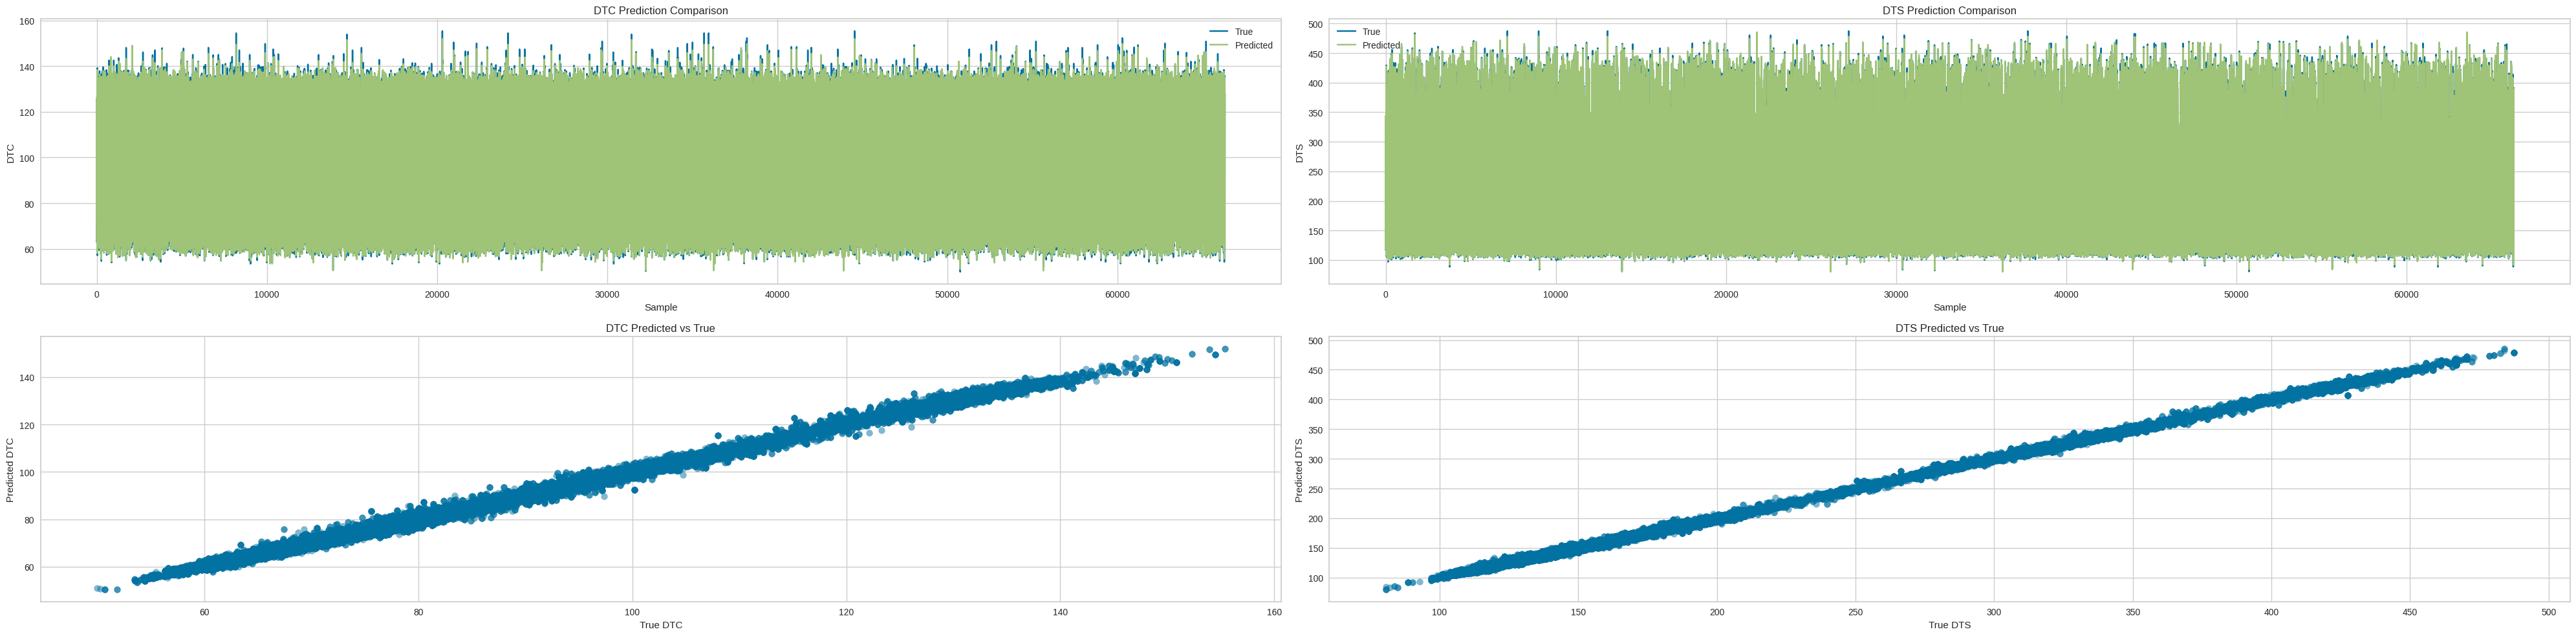

In [94]:
def result_plot(y_predict, y_real):
    print('Combined R2 score:', '{:.5f}'.format(r2_score(y_real, y_predict)))

    dtc_real = y_real[:, 0]
    dtc_pred = y_predict[:, 0]
    dts_real = y_real[:, 1]
    dts_pred = y_predict[:, 1]

    print('DTC R2:', '{:.5f}'.format(r2_score(dtc_real, dtc_pred)))
    print('DTS R2:', '{:.5f}'.format(r2_score(dts_real, dts_pred)))

    fig, axs = plt.subplots(2, 2, figsize=(40, 10))

    axs[0, 0].plot(dtc_real, label='True')
    axs[0, 0].plot(dtc_pred, label='Predicted')
    axs[0, 0].set_title('DTC Prediction Comparison')
    axs[0, 0].set_xlabel('Sample')
    axs[0, 0].set_ylabel('DTC')
    axs[0, 0].legend()

    axs[0, 1].plot(dts_real, label='True')
    axs[0, 1].plot(dts_pred, label='Predicted')
    axs[0, 1].set_title('DTS Prediction Comparison')
    axs[0, 1].set_xlabel('Sample')
    axs[0, 1].set_ylabel('DTS')
    axs[0, 1].legend()

    axs[1, 0].scatter(dtc_real, dtc_pred, alpha=0.5)
    axs[1, 0].set_title('DTC Predicted vs True')
    axs[1, 0].set_xlabel('True DTC')
    axs[1, 0].set_ylabel('Predicted DTC')

    axs[1, 1].scatter(dts_real, dts_pred, alpha=0.5)
    axs[1, 1].set_title('DTS Predicted vs True')
    axs[1, 1].set_xlabel('True DTS')
    axs[1, 1].set_ylabel('Predicted DTS')

    plt.tight_layout()
    plt.show()


# Make predictions
y_pred_dtc = model_dtc.predict(X_test_dtc)
y_pred_dts = model_dts.predict(X_test_dts)

# Convert to numpy arrays if needed
y_test_dtc = y_test_dtc.to_numpy() if not isinstance(y_test_dtc, np.ndarray) else y_test_dtc
y_test_dts = y_test_dts.to_numpy() if not isinstance(y_test_dts, np.ndarray) else y_test_dts
y_pred_dtc = np.array(y_pred_dtc)
y_pred_dts = np.array(y_pred_dts)

# Combine predictions and true values for the plot function
y_real_combined = np.column_stack((y_test_dtc, y_test_dts))
y_pred_combined = np.column_stack((y_pred_dtc, y_pred_dts))

# Plot results
result_plot(y_pred_combined, y_real_combined)


RMSE of test data (DTC): 1.16
RMSE of test data (DTS): 2.38
Overall RMSE = 1.87


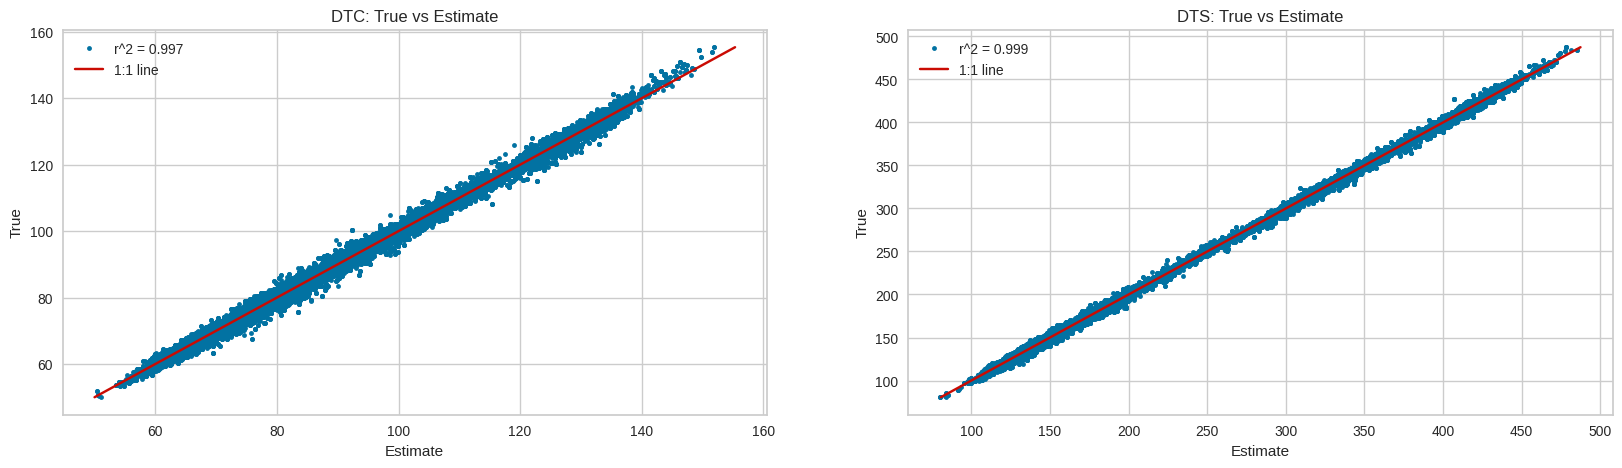

In [95]:
def plot_results(preds, reals):
    plt.figure(figsize=(20, 5))

    for i, label in enumerate(['DTC', 'DTS']):
        plt.subplot(1, 2, i+1)
        plt.plot(preds[:, i], reals[:, i], '.', label=f'r^2 = {r2_score(reals[:, i], preds[:, i]):.3f}')
        plt.plot([reals[:, i].min(), reals[:, i].max()],
                 [reals[:, i].min(), reals[:, i].max()], 'r', label='1:1 line')
        plt.title(f'{label}: True vs Estimate')
        plt.xlabel('Estimate')
        plt.ylabel('True')
        plt.legend()

    MSE_0 = mean_squared_error(reals[:, 0], preds[:, 0])
    RMSE_0 = np.sqrt(MSE_0)
    MSE_1 = mean_squared_error(reals[:, 1], preds[:, 1])
    RMSE_1 = np.sqrt(MSE_1)

    print(f'RMSE of test data (DTC): {RMSE_0:.2f}')
    print(f'RMSE of test data (DTS): {RMSE_1:.2f}')
    print(f'Overall RMSE = {np.sqrt((MSE_0 + MSE_1) / 2):.2f}')


plot_results(y_pred_combined, y_real_combined)